# 📈 End-to-End Stock Market Prediction System
## A Complete Portfolio-Level Machine Learning Project

---

**Author:** *Your Name*  
**Date:** March 2026  
**Tech Stack:** Python · Pandas · Scikit-Learn · TensorFlow/Keras · FastAPI · Streamlit · Docker

---

### Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | Project Overview | Problem statement, goals, and expected outputs |
| 2 | System Architecture | Complete architecture diagram and component roles |
| 3 | Dataset & Data Collection | APIs, data fields, and download code |
| 4 | Data Preprocessing | Cleaning, scaling, and sliding window creation |
| 5 | Feature Engineering | Technical indicators (SMA, EMA, RSI, MACD, Bollinger Bands) |
| 6 | Machine Learning Models | Linear Regression, Random Forest, SVR, LSTM |
| 7 | Deep Learning Architecture | Detailed LSTM network design |
| 8 | Model Training | Training pipeline, early stopping, hyperparameters |
| 9 | Model Evaluation | MSE, RMSE, MAE, R² and model comparison |
| 10 | Prediction System | Next-day price, trends, buy/sell signals |
| 11 | Backend API | FastAPI endpoints and workflow |
| 12 | Frontend Dashboard | Streamlit interactive dashboard |
| 13 | Deployment | Docker, cloud platforms |
| 14 | Project Folder Structure | Professional GitHub-ready layout |
| 15 | Advanced Improvements | Sentiment analysis, Transformers, RL agents |
| 16 | Portfolio & Resume Value | Skills demonstrated and career relevance |

---
# Section 1: Project Overview
---

## 🎯 What Problem Does This Project Solve?

Stock market prediction is one of the most challenging problems in finance and machine learning. Investors, traders, and financial institutions constantly seek tools that can forecast future stock prices to make informed decisions. This project builds a **complete machine learning pipeline** that:

1. **Collects** real historical stock market data from public APIs
2. **Processes and engineers** meaningful features from raw price data
3. **Trains multiple ML/DL models** to learn patterns in price movements
4. **Evaluates and compares** model performance rigorously
5. **Serves predictions** through a REST API
6. **Visualizes results** in an interactive web dashboard

## 🧠 Why Is Stock Prediction Difficult?

Stock prices are influenced by an enormous number of factors, making prediction inherently challenging:

| Challenge | Explanation |
|-----------|------------|
| **Non-stationarity** | Statistical properties of stock data change over time |
| **High noise-to-signal ratio** | Daily price movements contain more random noise than predictable pattern |
| **External influences** | Geopolitical events, earnings reports, tweets, pandemics—all cause unpredictable jumps |
| **Efficient Market Hypothesis** | Academic theory suggests all known information is already priced in |
| **Regime changes** | Bull markets, bear markets, and crashes behave fundamentally differently |
| **Feedback loops** | If a prediction method works widely, the market adapts and it stops working |

> **Important:** No model can predict the stock market with certainty. This project demonstrates ML engineering skills, not a guaranteed trading strategy.

## 📊 What Outputs Will the System Produce?

| Output | Type | Description |
|--------|------|-------------|
| **Next-day price prediction** | Regression (float) | Predicted closing price for the next trading day |
| **Price trend prediction** | Classification (UP/DOWN) | Direction of price movement |
| **Buy / Sell signal** | Signal (BUY/SELL/HOLD) | Action recommendation based on model + indicators |
| **Visualization dashboard** | Web UI | Interactive charts with predictions, indicators, and signals |
| **REST API** | JSON endpoints | Programmatic access to predictions |

## 🏗️ What Makes This a Strong Portfolio Project?

This project demonstrates **7 core skills** that hiring managers look for:

```
✅ Data Engineering        — collecting and processing real-world financial data
✅ Feature Engineering      — creating domain-specific features (technical indicators)  
✅ Machine Learning         — implementing and comparing multiple algorithms
✅ Deep Learning            — building LSTM neural networks for sequence prediction
✅ API Development          — serving models through production-grade APIs
✅ Full-Stack Development   — building interactive frontend dashboards
✅ MLOps & Deployment       — containerizing and deploying the complete system
```

---
# Section 2: System Architecture
---

## 🏛️ High-Level Architecture

The system follows a **layered pipeline architecture** where data flows from left to right through distinct processing stages:

```
┌─────────────────────────────────────────────────────────────────────────────────────┐
│                        STOCK MARKET PREDICTION SYSTEM                               │
│                                                                                     │
│  ┌──────────┐   ┌──────────────┐   ┌─────────────┐   ┌──────────────┐              │
│  │  DATA     │   │  DATA        │   │  FEATURE    │   │  MODEL       │              │
│  │  SOURCES  │──▶│  PROCESSING  │──▶│  ENGINEERING│──▶│  TRAINING    │              │
│  │          │   │              │   │             │   │              │              │
│  │ • Yahoo  │   │ • Cleaning   │   │ • SMA/EMA  │   │ • Lin. Reg.  │              │
│  │   Finance│   │ • Scaling    │   │ • RSI/MACD │   │ • Random For.│              │
│  │ • Alpha  │   │ • Windowing  │   │ • Bollinger│   │ • SVR        │              │
│  │   Vantage│   │ • Splitting  │   │ • Momentum │   │ • LSTM       │              │
│  └──────────┘   └──────────────┘   └─────────────┘   └──────┬───────┘              │
│                                                              │                      │
│                                                              ▼                      │
│  ┌──────────────┐   ┌──────────────┐   ┌─────────────────────────────┐              │
│  │  FRONTEND    │   │  PREDICTION  │   │  MODEL EVALUATION           │              │
│  │  DASHBOARD   │◀──│  API         │◀──│                             │              │
│  │              │   │  (FastAPI)   │   │  • MSE, RMSE, MAE, R²      │              │
│  │ • Streamlit  │   │              │   │  • Model Comparison         │              │
│  │ • Charts     │   │ • /predict   │   │  • Best Model Selection     │              │
│  │ • Signals    │   │ • /data      │   │  • Saved Model (.h5/.pkl)   │              │
│  └──────────────┘   └──────────────┘   └─────────────────────────────┘              │
│                                                                                     │
│  ┌─────────────────────────────────────────────────────────────────────────────────┐ │
│  │  DEPLOYMENT: Docker Container → Cloud (AWS / GCP / Render / Railway)           │ │
│  └─────────────────────────────────────────────────────────────────────────────────┘ │
└─────────────────────────────────────────────────────────────────────────────────────┘
```

## 🔍 Component Breakdown

### Layer 1: Data Sources
**Role:** Provide raw historical stock market data.

| Source | Type | Cost | Rate Limit |
|--------|------|------|------------|
| Yahoo Finance (`yfinance`) | REST API via Python wrapper | Free | Generous (unofficial) |
| Alpha Vantage | REST API with key | Free tier (5 calls/min) | 500 calls/day |

We primarily use **Yahoo Finance** because it's free, reliable, and provides all the OHLCV (Open, High, Low, Close, Volume) data we need.

---

### Layer 2: Data Processing
**Role:** Clean raw data and prepare it for model consumption.

- **Missing value handling** — Forward-fill, backward-fill, or interpolation for gaps in trading data
- **Sorting** — Ensure chronological order (oldest → newest)
- **Anomaly removal** — Filter out stock splits, extreme outliers
- **Scaling** — Normalize values to [0, 1] range using MinMaxScaler
- **Window creation** — Sliding window of N days → predict day N+1

---

### Layer 3: Feature Engineering
**Role:** Create domain-specific features that help models learn patterns.

Raw OHLCV data alone is insufficient. Technical indicators like Moving Averages, RSI, and MACD encode momentum, trend, and volatility information that models can exploit.

---

### Layer 4: Model Training
**Role:** Train multiple algorithms and select the best performer.

We implement 4 models of increasing complexity:
1. **Linear Regression** — baseline
2. **Random Forest** — ensemble method
3. **SVR** — kernel-based regression
4. **LSTM** — deep learning for sequences

---

### Layer 5: Model Evaluation
**Role:** Objectively compare models using standard regression metrics.

---

### Layer 6: Prediction API
**Role:** Serve the best model's predictions through HTTP endpoints.

Built with **FastAPI** for automatic OpenAPI docs, async support, and high performance.

---

### Layer 7: Frontend Dashboard
**Role:** Provide an interactive user interface for exploring predictions.

Built with **Streamlit** for rapid prototyping (or React.js for production).

---

### Layer 8: Deployment
**Role:** Package everything into a deployable container and host it in the cloud.

---
# Section 3: Dataset and Data Collection
---

## 📡 Where Does the Data Come From?

We use the **Yahoo Finance API** through the `yfinance` Python library. This provides free access to historical OHLCV data for thousands of publicly traded stocks.

### Data Fields Collected

| Field | Description | Example |
|-------|-------------|---------|
| `Date` | Trading date | 2025-01-15 |
| `Open` | Price at market open | $150.25 |
| `High` | Highest price during the day | $153.80 |
| `Low` | Lowest price during the day | $149.10 |
| `Close` | Price at market close | $152.50 |
| `Adj Close` | Close price adjusted for splits/dividends | $152.50 |
| `Volume` | Number of shares traded | 45,000,000 |

### Why OHLCV Data?

- **Open/Close** — Show the daily price range start and end points
- **High/Low** — Show intraday volatility
- **Volume** — Shows trading activity and interest (high volume = strong conviction in price move)
- **Adj Close** — Accounts for corporate actions, making historical comparison valid

### Alternative Data Source: Alpha Vantage

```python
# Alpha Vantage requires a free API key from: https://www.alphavantage.co/support/#api-key
# Example (not used in main pipeline):
# import requests
# url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=AAPL&apikey=YOUR_KEY&outputsize=full'
# response = requests.get(url)
# data = response.json()
```

We prefer `yfinance` because it requires **no API key** and has generous rate limits.

In [1]:
# ============================================================
# Section 3: Install Required Libraries
# ============================================================
# Run this cell first to install all dependencies

import subprocess
import sys

packages = [
    'yfinance',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'tensorflow',
    'plotly',
    'ta',           # Technical Analysis library
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [2]:
# ============================================================
# Section 3: Data Collection — Download Historical Stock Data
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
TICKER = 'AAPL'            # Stock ticker symbol (Apple Inc.)
START_DATE = '2018-01-01'   # 8+ years of historical data
END_DATE = '2026-03-01'     # Up to current date
WINDOW_SIZE = 60            # Use 60 days of history to predict next day

# --- Download Data ---
print(f"📥 Downloading {TICKER} data from {START_DATE} to {END_DATE}...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# Flatten MultiIndex columns if present (yfinance sometimes returns MultiIndex)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# --- Basic Exploration ---
print(f"\n✅ Downloaded {len(df)} trading days of data")
print(f"📅 Date range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
print(f"\n📋 Columns: {list(df.columns)}")
print(f"\n🔍 First 5 rows:")
df.head()

📥 Downloading AAPL data from 2018-01-01 to 2026-03-01...

✅ Downloaded 2050 trading days of data
📅 Date range: 2018-01-02 to 2026-02-27

📋 Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

🔍 First 5 rows:


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.304184,40.313545,39.602265,39.812843,102223600
2018-01-03,40.297161,40.839980,40.233991,40.367354,118071600
2018-01-04,40.484333,40.587282,40.262059,40.369685,89738400
2018-01-05,40.945274,41.031843,40.489028,40.580277,94640000
2018-01-08,40.793182,41.087987,40.694911,40.793182,82271200


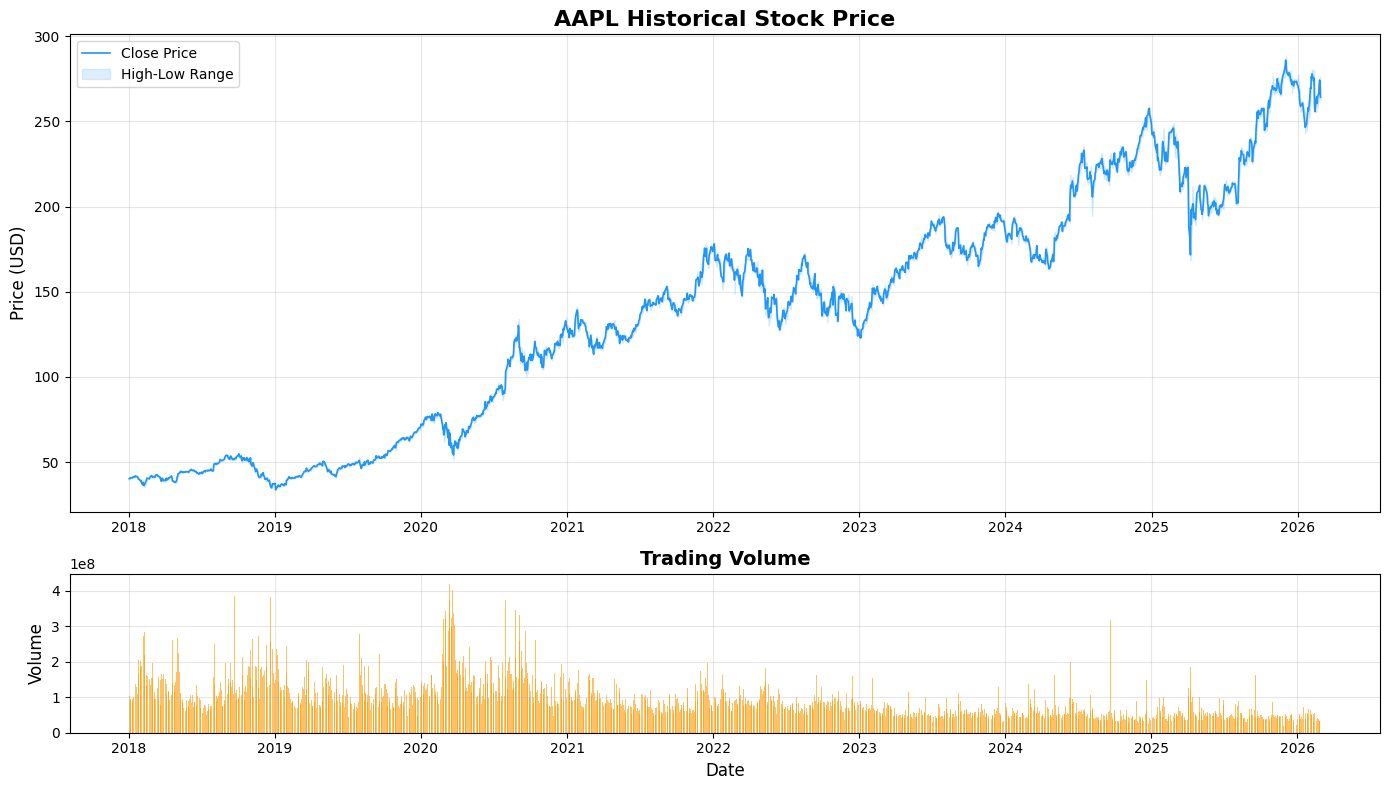


📊 Summary Statistics:
Price     Open     High      Low    Close        Volume
count  2050.00  2050.00  2050.00  2050.00  2.050000e+03
mean    137.70   139.22   136.29   137.82  9.362065e+07
std      68.34    69.01    67.72    68.39  5.430540e+07
min      34.19    34.61    33.72    33.77  1.791060e+07
25%      64.96    66.52    64.28    65.58  5.482532e+07
50%     143.65   145.30   142.29   143.69  8.019745e+07
75%     186.22   187.61   185.16   186.33  1.141292e+08
max     285.93   288.35   283.04   285.92  4.265100e+08


In [3]:
# ============================================================
# Section 3: Visualize Raw Stock Data
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Price chart
axes[0].plot(df.index, df['Close'], color='#2196F3', linewidth=1.2, label='Close Price')
axes[0].fill_between(df.index, df['Low'], df['High'], alpha=0.15, color='#2196F3', label='High-Low Range')
axes[0].set_title(f'{TICKER} Historical Stock Price', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Volume chart
axes[1].bar(df.index, df['Volume'], color='#FF9800', alpha=0.6, width=1.5)
axes[1].set_title('Trading Volume', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volume', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary Statistics ---
print("\n📊 Summary Statistics:")
print("=" * 50)
print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2))

---
# Section 4: Data Preprocessing
---

## 🧹 Why Is Preprocessing Critical?

Raw stock data cannot be fed directly into ML models. Preprocessing ensures:

1. **No missing values** — Models crash or learn wrong patterns from NaN/null values
2. **Correct temporal order** — Time series models require strict chronological order
3. **No anomalies** — Stock splits, data errors, and extreme outliers distort learning
4. **Normalized scale** — Neural networks train faster and more stably with values in [0, 1]
5. **Proper input shape** — Models need fixed-size input windows

## 📐 The Sliding Window Technique

For time series prediction, we use a **sliding window** approach. The idea is simple:

```
Day 1-60    → Predict Day 61
Day 2-61    → Predict Day 62
Day 3-62    → Predict Day 63
...
Day N-60 to N-1 → Predict Day N
```

**Why 60 days?** This is approximately 3 months of trading data — enough to capture medium-term trends while being short enough to remain relevant. This is a hyperparameter you can tune.

```
┌──────────────────────────────────────────────────────────────────┐
│  SLIDING WINDOW EXAMPLE (window_size = 5, simplified)           │
│                                                                  │
│  Raw Data:  [10, 12, 11, 13, 15, 14, 16, 18, 17, 19]           │
│                                                                  │
│  Window 1:  [10, 12, 11, 13, 15] → Target: 14                  │
│  Window 2:  [12, 11, 13, 15, 14] → Target: 16                  │
│  Window 3:  [11, 13, 15, 14, 16] → Target: 18                  │
│  Window 4:  [13, 15, 14, 16, 18] → Target: 17                  │
│  Window 5:  [15, 14, 16, 18, 17] → Target: 19                  │
└──────────────────────────────────────────────────────────────────┘
```

## 🔄 Feature Scaling: MinMaxScaler

Neural networks (especially LSTMs) work best with inputs in the range [0, 1].

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

**Why not StandardScaler?** MinMaxScaler preserves the shape of the distribution and bounds values, which is better for LSTMs. StandardScaler centers data around 0 with unit variance, which is fine for tree-based and linear models.

## ⚠️ Time Series Train/Test Split

**Critical rule:** Never use random shuffling for time series data!

```
❌ WRONG:  Random 80/20 split (future data leaks into training)
✅ RIGHT:  Chronological split (train on past, test on future)

Timeline: ──────────────────────────────────────▶
           [====== TRAINING (80%) ======][= TEST (20%) =]
           Jan 2018 ─────── Jul 2024    Aug 2024 ── Mar 2026
```

If you randomly shuffle, the model "sees" future prices during training — this is called **data leakage** and produces artificially inflated performance that won't work in production.

In [4]:
# ============================================================
# Section 4: Data Preprocessing Pipeline
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# --- Step 1: Handle Missing Values ---
print("🔍 Missing values BEFORE cleaning:")
print(df.isnull().sum())
print()

# Forward fill (use previous day's value for missing days)
df_clean = df.copy()
df_clean = df_clean.ffill()   # Forward fill
df_clean = df_clean.bfill()   # Backward fill for any remaining NaN at start

print("✅ Missing values AFTER cleaning:")
print(df_clean.isnull().sum())

# --- Step 2: Sort by Date (ensure chronological order) ---
df_clean = df_clean.sort_index()
print(f"\n📅 Data sorted chronologically: {df_clean.index[0].strftime('%Y-%m-%d')} → {df_clean.index[-1].strftime('%Y-%m-%d')}")

# --- Step 3: Remove Anomalies (optional — filter extreme outliers) ---
# Calculate daily returns
daily_returns = df_clean['Close'].pct_change()

# Flag days with >20% price change (likely stock split artifacts or data errors)
anomalies = daily_returns[abs(daily_returns) > 0.20]
print(f"\n⚠️  Found {len(anomalies)} days with >20% price change (potential anomalies)")
if len(anomalies) > 0:
    print(anomalies)

# --- Step 4: Feature Scaling ---
# We'll scale the 'Close' price for LSTM model input
scaler = MinMaxScaler(feature_range=(0, 1))
close_prices = df_clean['Close'].values.reshape(-1, 1)
scaled_data = scaler.fit_transform(close_prices)

print(f"\n📏 Scaling applied:")
print(f"   Original range: ${close_prices.min():.2f} — ${close_prices.max():.2f}")
print(f"   Scaled range:   {scaled_data.min():.4f} — {scaled_data.max():.4f}")

# --- Step 5: Create Sliding Windows ---
def create_sequences(data, window_size):
    """
    Create sliding window sequences for time series prediction.
    
    Parameters:
        data: Scaled price data (numpy array)
        window_size: Number of past days to use as input
    
    Returns:
        X: Input sequences of shape (num_samples, window_size, 1)
        y: Target values of shape (num_samples,)
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])  # Previous 'window_size' days
        y.append(data[i, 0])                   # Next day's price
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, WINDOW_SIZE)

print(f"\n📦 Sliding Window Results:")
print(f"   Window size: {WINDOW_SIZE} days")
print(f"   Total samples created: {len(X)}")
print(f"   Input shape (X): {X.shape}  — ({len(X)} samples × {WINDOW_SIZE} time steps)")
print(f"   Target shape (y): {y.shape}  — ({len(y)} target values)")

# --- Step 6: Time Series Train/Test Split (80/20 chronological) ---
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"\n✂️  Train/Test Split (Chronological):")
print(f"   Training samples: {len(X_train)} ({split_ratio*100:.0f}%)")
print(f"   Testing samples:  {len(X_test)} ({(1-split_ratio)*100:.0f}%)")

# Reshape X for LSTM: (samples, time_steps, features)
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"\n🔄 LSTM Input Shape:")
print(f"   X_train: {X_train_lstm.shape}  — (samples, time_steps, features)")
print(f"   X_test:  {X_test_lstm.shape}")

🔍 Missing values BEFORE cleaning:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

✅ Missing values AFTER cleaning:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

📅 Data sorted chronologically: 2018-01-02 → 2026-02-27

⚠️  Found 0 days with >20% price change (potential anomalies)

📏 Scaling applied:
   Original range: $33.77 — $285.92
   Scaled range:   0.0000 — 1.0000

📦 Sliding Window Results:
   Window size: 60 days
   Total samples created: 1990
   Input shape (X): (1990, 60)  — (1990 samples × 60 time steps)
   Target shape (y): (1990,)  — (1990 target values)

✂️  Train/Test Split (Chronological):
   Training samples: 1592 (80%)
   Testing samples:  398 (20%)

🔄 LSTM Input Shape:
   X_train: (1592, 60, 1)  — (samples, time_steps, features)
   X_test:  (398, 60, 1)


---
# Section 5: Feature Engineering
---

## 🛠️ Why Feature Engineering Matters

Raw OHLCV data tells you what happened, but **technical indicators** tell you what it means:

- **Trend** — Is the stock going up, down, or sideways?
- **Momentum** — How fast is the price moving? Is it accelerating?
- **Volatility** — How much is the price fluctuating?
- **Overbought/Oversold** — Has the price moved too far, too fast?

Models trained on raw prices alone perform significantly worse than models trained with engineered features. Feature engineering is often the difference between a mediocre and a great model.

## 📊 Technical Indicators We'll Implement

### 1. Simple Moving Average (SMA)
**What it does:** Smooths out price data by averaging over a fixed window.

$$SMA_n = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

- **SMA-20:** Short-term trend (20 trading days ≈ 1 month)
- **SMA-50:** Medium-term trend
- **Signal:** When short SMA crosses above long SMA → bullish; below → bearish

### 2. Exponential Moving Average (EMA)
**What it does:** Like SMA but gives more weight to recent prices, making it more responsive.

$$EMA_t = P_t \times k + EMA_{t-1} \times (1 - k), \quad k = \frac{2}{n + 1}$$

### 3. Relative Strength Index (RSI)
**What it does:** Measures momentum on a scale of 0-100.

$$RSI = 100 - \frac{100}{1 + RS}, \quad RS = \frac{\text{Avg Gain over } n \text{ periods}}{\text{Avg Loss over } n \text{ periods}}$$

- **RSI > 70:** Overbought (price may drop)
- **RSI < 30:** Oversold (price may rise)
- Typically uses 14-day window

### 4. MACD (Moving Average Convergence Divergence)
**What it does:** Shows relationship between two EMAs to identify trend changes.

$$MACD = EMA_{12} - EMA_{26}$$
$$Signal\;Line = EMA_9(MACD)$$
$$Histogram = MACD - Signal\;Line$$

- **MACD crosses above Signal Line:** Buy signal
- **MACD crosses below Signal Line:** Sell signal

### 5. Bollinger Bands
**What it does:** Creates a price channel based on volatility.

$$Upper = SMA_{20} + 2 \times \sigma_{20}$$
$$Lower = SMA_{20} - 2 \times \sigma_{20}$$

- Price touching upper band → potentially overbought
- Price touching lower band → potentially oversold
- Band width indicates volatility

### 6. Price Momentum
**What it does:** Measures the rate of price change.

$$Momentum = P_t - P_{t-n}$$

### 7. Volatility (Standard Deviation of Returns)
**What it does:** Measures how much the price fluctuates.

$$Volatility = \sigma(\text{daily returns over } n \text{ days})$$

In [5]:
# ============================================================
# Section 5: Feature Engineering — Compute Technical Indicators
# ============================================================

def compute_technical_indicators(df):
    """
    Compute all technical indicators and add them as new columns.
    
    Parameters:
        df: DataFrame with OHLCV data
    
    Returns:
        DataFrame with additional technical indicator columns
    """
    data = df.copy()
    close = data['Close']
    high = data['High']
    low = data['Low']
    
    # ---- 1. Simple Moving Averages (SMA) ----
    data['SMA_20'] = close.rolling(window=20).mean()
    data['SMA_50'] = close.rolling(window=50).mean()
    data['SMA_200'] = close.rolling(window=200).mean()
    
    # ---- 2. Exponential Moving Averages (EMA) ----
    data['EMA_12'] = close.ewm(span=12, adjust=False).mean()
    data['EMA_26'] = close.ewm(span=26, adjust=False).mean()
    
    # ---- 3. Relative Strength Index (RSI) ----
    delta = close.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
    
    # ---- 4. MACD ----
    data['MACD'] = data['EMA_12'] - data['EMA_26']
    data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
    data['MACD_Histogram'] = data['MACD'] - data['MACD_Signal']
    
    # ---- 5. Bollinger Bands ----
    sma_20 = close.rolling(window=20).mean()
    std_20 = close.rolling(window=20).std()
    data['BB_Upper'] = sma_20 + (std_20 * 2)
    data['BB_Lower'] = sma_20 - (std_20 * 2)
    data['BB_Width'] = data['BB_Upper'] - data['BB_Lower']
    
    # ---- 6. Price Momentum ----
    data['Momentum_10'] = close - close.shift(10)
    data['Momentum_30'] = close - close.shift(30)
    
    # ---- 7. Volatility (20-day rolling standard deviation of returns) ----
    data['Daily_Return'] = close.pct_change()
    data['Volatility_20'] = data['Daily_Return'].rolling(window=20).std()
    
    # ---- 8. Additional useful features ----
    data['Price_Range'] = high - low                         # Intraday range
    data['Price_Change'] = close - close.shift(1)            # Daily change
    data['Volume_SMA_20'] = data['Volume'].rolling(20).mean()  # Volume trend
    
    return data

# --- Apply feature engineering ---
df_features = compute_technical_indicators(df_clean)

# Drop rows with NaN (caused by rolling window calculations)
initial_len = len(df_features)
df_features = df_features.dropna()
print(f"📊 Feature Engineering Complete!")
print(f"   Original rows: {initial_len}")
print(f"   After dropping NaN (from rolling windows): {len(df_features)}")
print(f"   Rows removed: {initial_len - len(df_features)}")
print(f"\n📋 All Features ({len(df_features.columns)} columns):")
for i, col in enumerate(df_features.columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\n🔍 Sample of engineered features (last 3 rows):")
df_features[['Close', 'SMA_20', 'SMA_50', 'RSI', 'MACD', 'BB_Upper', 'BB_Lower', 'Volatility_20']].tail(3)

📊 Feature Engineering Complete!
   Original rows: 2050
   After dropping NaN (from rolling windows): 1851
   Rows removed: 199

📋 All Features (24 columns):
    1. Close
    2. High
    3. Low
    4. Open
    5. Volume
    6. SMA_20
    7. SMA_50
    8. SMA_200
    9. EMA_12
   10. EMA_26
   11. RSI
   12. MACD
   13. MACD_Signal
   14. MACD_Histogram
   15. BB_Upper
   16. BB_Lower
   17. BB_Width
   18. Momentum_10
   19. Momentum_30
   20. Daily_Return
   21. Volatility_20
   22. Price_Range
   23. Price_Change
   24. Volume_SMA_20

🔍 Sample of engineered features (last 3 rows):


Price,Close,SMA_20,SMA_50,RSI,MACD,BB_Upper,BB_Lower,Volatility_20
Date,,,,,,,,
2026-02-25,274.230011,267.472775,265.495391,48.163678,1.344415,282.091499,252.854051,0.019945
2026-02-26,272.950012,268.310262,265.393994,47.552395,1.681276,282.105853,254.514670,0.019886
2026-02-27,264.179993,268.617334,265.200519,38.924889,1.226437,281.705514,255.529154,0.021376


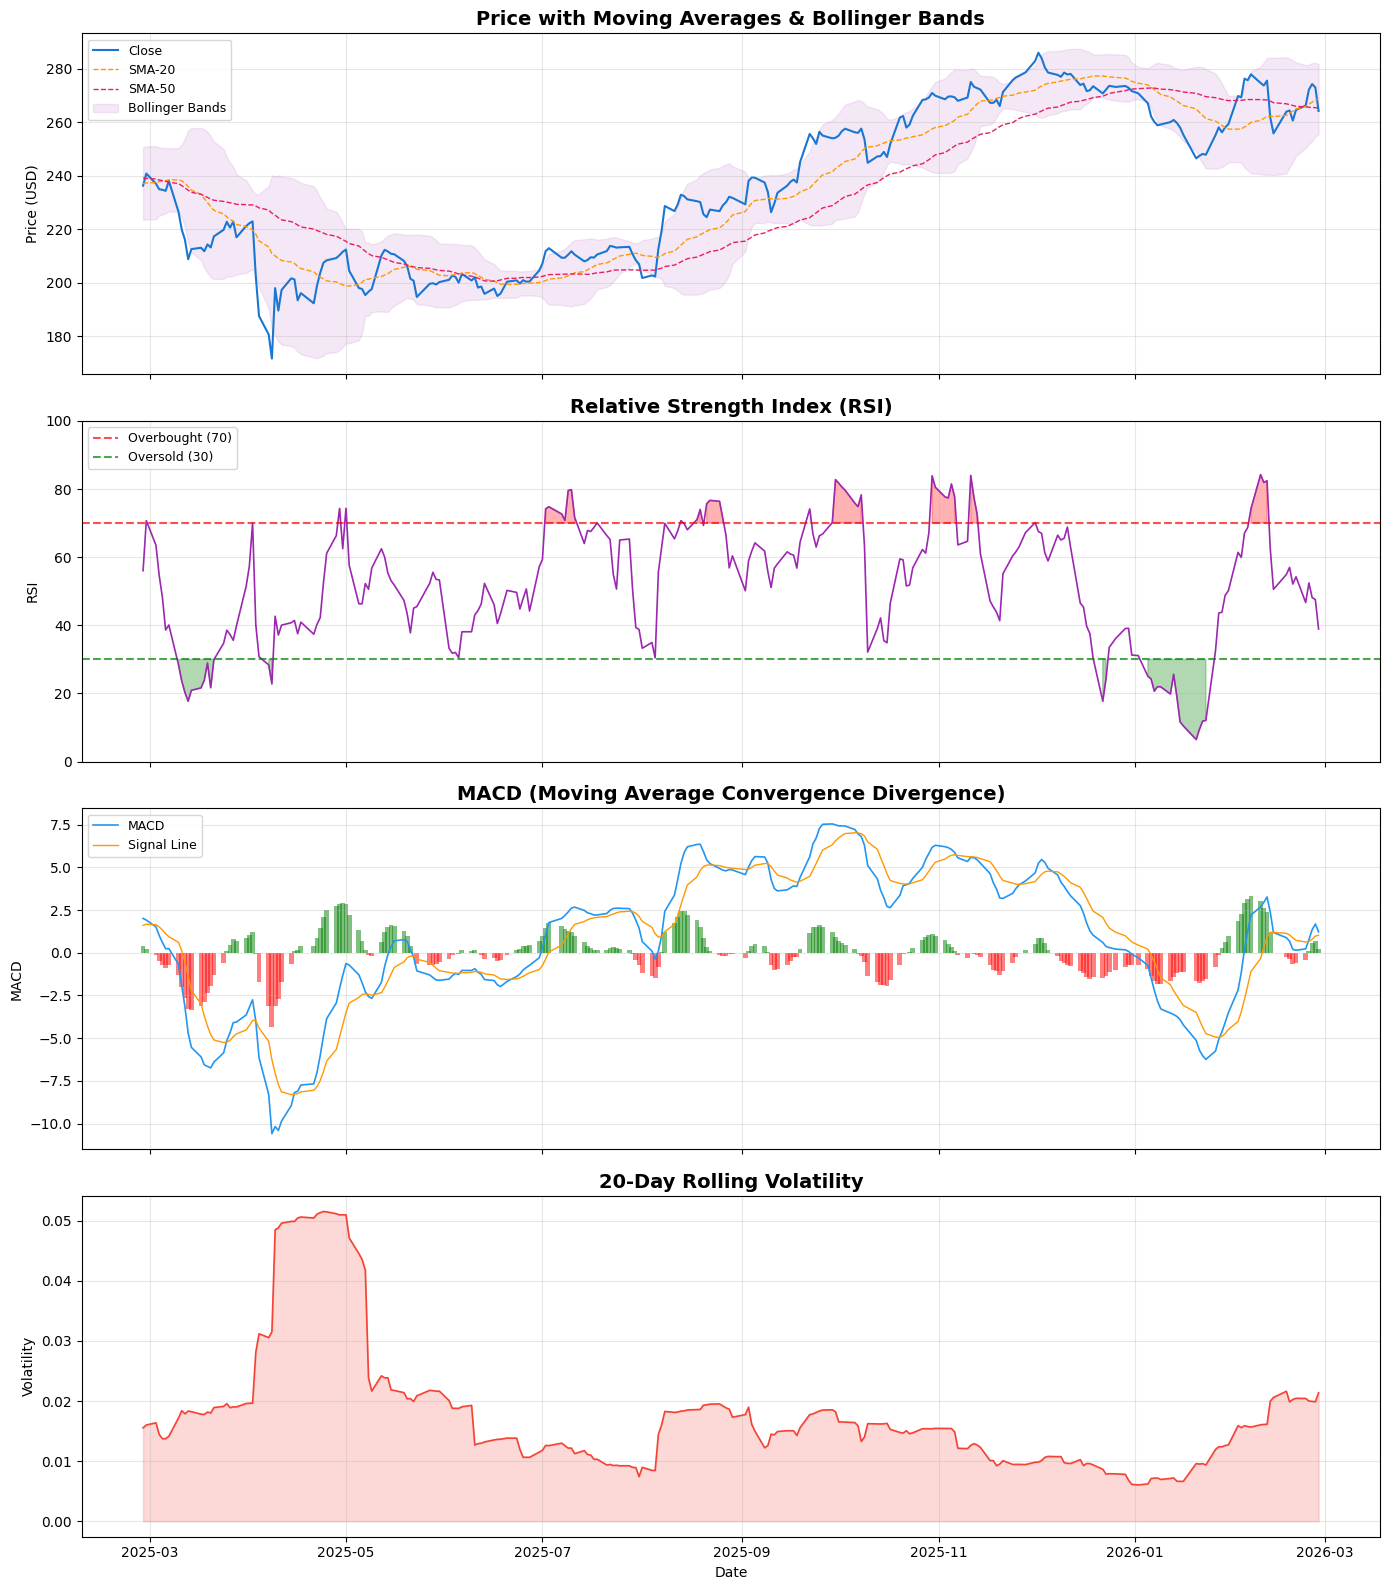

In [6]:
# ============================================================
# Section 5: Visualize Technical Indicators
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Subset for cleaner visualization (last 252 trading days ≈ 1 year)
plot_df = df_features.tail(252)

# --- Plot 1: Price with Moving Averages and Bollinger Bands ---
axes[0].plot(plot_df.index, plot_df['Close'], label='Close', linewidth=1.5, color='#1976D2')
axes[0].plot(plot_df.index, plot_df['SMA_20'], label='SMA-20', linewidth=1, linestyle='--', color='#FF9800')
axes[0].plot(plot_df.index, plot_df['SMA_50'], label='SMA-50', linewidth=1, linestyle='--', color='#E91E63')
axes[0].fill_between(plot_df.index, plot_df['BB_Upper'], plot_df['BB_Lower'], 
                      alpha=0.1, color='#9C27B0', label='Bollinger Bands')
axes[0].set_title('Price with Moving Averages & Bollinger Bands', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: RSI ---
axes[1].plot(plot_df.index, plot_df['RSI'], color='#9C27B0', linewidth=1.2)
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].fill_between(plot_df.index, 70, plot_df['RSI'], where=plot_df['RSI'] >= 70, 
                      alpha=0.3, color='red')
axes[1].fill_between(plot_df.index, 30, plot_df['RSI'], where=plot_df['RSI'] <= 30, 
                      alpha=0.3, color='green')
axes[1].set_title('Relative Strength Index (RSI)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

# --- Plot 3: MACD ---
axes[2].plot(plot_df.index, plot_df['MACD'], label='MACD', color='#2196F3', linewidth=1.2)
axes[2].plot(plot_df.index, plot_df['MACD_Signal'], label='Signal Line', color='#FF9800', linewidth=1)
colors = ['green' if v >= 0 else 'red' for v in plot_df['MACD_Histogram']]
axes[2].bar(plot_df.index, plot_df['MACD_Histogram'], color=colors, alpha=0.5, width=1.5)
axes[2].set_title('MACD (Moving Average Convergence Divergence)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('MACD')
axes[2].legend(loc='upper left', fontsize=9)
axes[2].grid(True, alpha=0.3)

# --- Plot 4: Volatility ---
axes[3].plot(plot_df.index, plot_df['Volatility_20'], color='#F44336', linewidth=1.2)
axes[3].fill_between(plot_df.index, 0, plot_df['Volatility_20'], alpha=0.2, color='#F44336')
axes[3].set_title('20-Day Rolling Volatility', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Volatility')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Section 6: Machine Learning Models
---

## 🤖 Model Comparison Strategy

We implement 4 models of increasing complexity. Each has different strengths for stock prediction:

### Model 1: Linear Regression (Baseline)

**How it works:** Fits a straight line (or hyperplane) that minimizes the sum of squared errors between predicted and actual values.

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$$

| Aspect | Detail |
|--------|--------|
| **Why useful** | Simple baseline to beat; if complex models can't outperform it, something is wrong |
| **Advantages** | Fast, interpretable, no hyperparameters |
| **Limitations** | Assumes linear relationship; stock prices are highly nonlinear |

---

### Model 2: Random Forest Regression

**How it works:** Builds many decision trees on random subsets of data and averages their predictions (bagging).

| Aspect | Detail |
|--------|--------|
| **Why useful** | Captures nonlinear patterns; resistant to overfitting due to ensemble averaging |
| **Advantages** | Handles noisy data well; feature importance built in; no feature scaling needed |
| **Limitations** | Cannot extrapolate beyond training data range; treats each input independently (no sequence awareness) |

---

### Model 3: Support Vector Regression (SVR)

**How it works:** Finds a hyperplane in high-dimensional space that fits the data within a margin (epsilon-tube). Uses kernel tricks to handle nonlinear patterns.

| Aspect | Detail |
|--------|--------|
| **Why useful** | Effective in high-dimensional spaces; robust to outliers |
| **Advantages** | Kernel trick allows nonlinear modeling; good generalization |
| **Limitations** | Slow on large datasets; sensitive to hyperparameters (C, epsilon, kernel) |

---

### Model 4: LSTM (Long Short-Term Memory) Neural Network

**How it works:** A special type of Recurrent Neural Network (RNN) designed to learn long-term dependencies in sequential data. Uses gates (forget, input, output) to control information flow.

| Aspect | Detail |
|--------|--------|
| **Why useful** | **Specifically designed for sequences** — learns temporal patterns in price history |
| **Advantages** | Captures long-term dependencies; handles variable-length sequences; state-of-the-art for time series |
| **Limitations** | Requires more data; slower to train; more hyperparameters to tune |

## 🏆 Why LSTM Is Best for Time Series

```
Linear Reg:   Sees each day independently → No temporal awareness
Random Forest: Sees feature vectors independently → No sequence order
SVR:          Sees feature vectors independently → No sequence order
LSTM:         Sees ordered sequence of 60 days → LEARNS temporal patterns ✅
```

LSTMs have a **memory cell** that can:
- **Remember** relevant patterns from weeks ago (via cell state)
- **Forget** irrelevant information (via forget gate)  
- **Update** with new information (via input gate)
- **Output** relevant predictions (via output gate)

In [7]:
# ============================================================
# Section 6: Train Traditional ML Models
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

# --- Store results for comparison ---
model_results = {}

# ==========================
# MODEL 1: Linear Regression
# ==========================
print("=" * 60)
print("🔵 MODEL 1: Linear Regression")
print("=" * 60)

start_time = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_time = time.time() - start_time

lr_predictions = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

model_results['Linear Regression'] = {
    'predictions': lr_predictions,
    'MSE': lr_mse, 'RMSE': lr_rmse, 'MAE': lr_mae, 'R2': lr_r2,
    'time': lr_time
}

print(f"   MSE:  {lr_mse:.6f}")
print(f"   RMSE: {lr_rmse:.6f}")
print(f"   MAE:  {lr_mae:.6f}")
print(f"   R²:   {lr_r2:.6f}")
print(f"   Training time: {lr_time:.2f}s")

# ==========================
# MODEL 2: Random Forest
# ==========================
print(f"\n{'=' * 60}")
print("🟢 MODEL 2: Random Forest Regression")
print("=" * 60)

start_time = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,       # Number of trees
    max_depth=20,           # Maximum tree depth
    min_samples_split=5,    # Minimum samples to split
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time

rf_predictions = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

model_results['Random Forest'] = {
    'predictions': rf_predictions,
    'MSE': rf_mse, 'RMSE': rf_rmse, 'MAE': rf_mae, 'R2': rf_r2,
    'time': rf_time
}

print(f"   MSE:  {rf_mse:.6f}")
print(f"   RMSE: {rf_rmse:.6f}")
print(f"   MAE:  {rf_mae:.6f}")
print(f"   R²:   {rf_r2:.6f}")
print(f"   Training time: {rf_time:.2f}s")

# ==========================
# MODEL 3: SVR
# ==========================
print(f"\n{'=' * 60}")
print("🟡 MODEL 3: Support Vector Regression (SVR)")
print("=" * 60)

start_time = time.time()
svr_model = SVR(
    kernel='rbf',     # Radial Basis Function kernel (handles nonlinearity)
    C=100,            # Regularization parameter
    epsilon=0.01,     # Epsilon-tube width
    gamma='scale'     # Kernel coefficient
)
svr_model.fit(X_train, y_train)
svr_time = time.time() - start_time

svr_predictions = svr_model.predict(X_test)

svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_r2 = r2_score(y_test, svr_predictions)

model_results['SVR'] = {
    'predictions': svr_predictions,
    'MSE': svr_mse, 'RMSE': svr_rmse, 'MAE': svr_mae, 'R2': svr_r2,
    'time': svr_time
}

print(f"   MSE:  {svr_mse:.6f}")
print(f"   RMSE: {svr_rmse:.6f}")
print(f"   MAE:  {svr_mae:.6f}")
print(f"   R²:   {svr_r2:.6f}")
print(f"   Training time: {svr_time:.2f}s")

🔵 MODEL 1: Linear Regression
   MSE:  0.000266
   RMSE: 0.016310
   MAE:  0.011264
   R²:   0.970702
   Training time: 0.01s

🟢 MODEL 2: Random Forest Regression
   MSE:  0.009423
   RMSE: 0.097072
   MAE:  0.069088
   R²:   -0.037829
   Training time: 0.29s

🟡 MODEL 3: Support Vector Regression (SVR)
   MSE:  0.077895
   RMSE: 0.279098
   MAE:  0.221624
   R²:   -7.579355
   Training time: 0.19s


---
# Section 7: Deep Learning Model — LSTM Architecture
---

## 🧬 LSTM Architecture in Detail

### What is an LSTM?

LSTM (Long Short-Term Memory) is a type of **Recurrent Neural Network** designed to handle the vanishing gradient problem that prevents standard RNNs from learning long-term dependencies.

### The LSTM Cell

Each LSTM cell has three gates:

```
                    ┌─────────────────────────────────────────────────┐
                    │                LSTM CELL                         │
                    │                                                  │
  Cell State ──────▶│──[×]──────────[+]──────────────────────▶ Cell State
  (long-term       │   │ Forget     │ Input                   (updated)
   memory)         │   │ Gate       │ Gate                             │
                    │   │            │                                  │
                    │  σ(Wf·[h,x]) σ(Wi·[h,x]) × tanh(Wc·[h,x])    │
                    │                                                  │
  Hidden State ────▶│                                    [×]──▶ Hidden State
  (short-term      │                              Output  │   (updated)
   memory)         │                              Gate    │            │
                    │                             σ(Wo·[h,x])         │
  Input ───────────▶│                              tanh(cell)         │
  (current         │                                                  │
   time step)      └─────────────────────────────────────────────────┘
```

- **Forget Gate (σ):** Decides what information to throw away from cell state
- **Input Gate (σ × tanh):** Decides what new information to store in cell state
- **Output Gate (σ × tanh):** Decides what to output based on cell state

### Our LSTM Network Architecture

```
┌──────────────────────────────────────────────────────────────────┐
│                     LSTM NETWORK ARCHITECTURE                    │
│                                                                  │
│  Input Layer                                                     │
│  ┌──────────────────────────────────┐                           │
│  │ Shape: (batch_size, 60, 1)       │  60 time steps, 1 feature │
│  └──────────────┬───────────────────┘                           │
│                 │                                                │
│  LSTM Layer 1   ▼                                                │
│  ┌──────────────────────────────────┐                           │
│  │ 128 units, return_sequences=True │  Returns output at each   │
│  └──────────────┬───────────────────┘  time step for next LSTM  │
│                 │                                                │
│  Dropout 1      ▼                                                │
│  ┌──────────────────────────────────┐                           │
│  │ rate = 0.2 (20% neurons dropped) │  Prevents overfitting     │
│  └──────────────┬───────────────────┘                           │
│                 │                                                │
│  LSTM Layer 2   ▼                                                │
│  ┌──────────────────────────────────┐                           │
│  │ 64 units, return_sequences=True  │  Learns higher-level      │
│  └──────────────┬───────────────────┘  temporal patterns         │
│                 │                                                │
│  Dropout 2      ▼                                                │
│  ┌──────────────────────────────────┐                           │
│  │ rate = 0.2                       │                            │
│  └──────────────┬───────────────────┘                           │
│                 │                                                │
│  LSTM Layer 3   ▼                                                │
│  ┌──────────────────────────────────┐                           │
│  │ 32 units, return_sequences=False │  Only returns final        │
│  └──────────────┬───────────────────┘  output (many-to-one)     │
│                 │                                                │
│  Dropout 3      ▼                                                │
│  ┌──────────────────────────────────┐                           │
│  │ rate = 0.2                       │                            │
│  └──────────────┬───────────────────┘                           │
│                 │                                                │
│  Dense Layer    ▼                                                │
│  ┌──────────────────────────────────┐                           │
│  │ 1 unit (predicted price)         │  Single regression output  │
│  └──────────────────────────────────┘                           │
│                                                                  │
│  Output: Predicted normalized stock price (0 to 1)               │
└──────────────────────────────────────────────────────────────────┘
```

### Why This Architecture?

| Design Choice | Reason |
|--------------|--------|
| **3 LSTM layers** | Deep enough to learn complex patterns, not so deep that training becomes unstable |
| **Decreasing units (128→64→32)** | Progressively compress temporal information into a meaningful representation |
| **Dropout (0.2)** | Prevents overfitting — randomly disables 20% of neurons during training |
| **return_sequences=True** (layers 1-2) | Passes full sequence output to the next LSTM layer |
| **return_sequences=False** (layer 3) | Outputs only the final prediction (many-to-one architecture) |
| **Dense(1)** | Single output neuron for the predicted price |

In [8]:
# ============================================================
# Section 7 & 8: Build and Train LSTM Model
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Fix random seed for reproducibility
tf.random.set_seed(42)

# ---- Build the LSTM Model ----
def build_lstm_model(input_shape):
    """
    Build a 3-layer LSTM model for stock price prediction.
    
    Parameters:
        input_shape: Tuple (time_steps, features) — e.g., (60, 1)
    
    Returns:
        Compiled Keras model
    """
    model = Sequential([
        # LSTM Layer 1: 128 units, returns sequences for stacking
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        
        # LSTM Layer 2: 64 units, returns sequences for next LSTM
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        
        # LSTM Layer 3: 32 units, only returns final output
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        
        # Dense output layer: single predicted value
        Dense(1)
    ])
    
    # Compile with Adam optimizer and MSE loss
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mae']
    )
    
    return model

# ---- Create model ----
lstm_model = build_lstm_model((WINDOW_SIZE, 1))

# ---- Print model summary ----
print("🧠 LSTM Model Architecture:")
print("=" * 60)
lstm_model.summary()

# Count total parameters
total_params = lstm_model.count_params()
print(f"\n📊 Total trainable parameters: {total_params:,}")

🧠 LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,417 (501.63 KB)

 Trainable params: 128,417 (501.63 KB)

 Non-trainable params: 0 (0.00 B)


📊 Total trainable parameters: 128,417


---
# Section 8: Model Training
---

## ⚙️ Training Configuration

| Hyperparameter | Value | Explanation |
|---------------|-------|-------------|
| **Loss Function** | Mean Squared Error (MSE) | Standard for regression; penalizes large errors more |
| **Optimizer** | Adam (lr=0.001) | Adaptive learning rate; works well out of the box |
| **Epochs** | 50 (with early stopping) | Maximum training iterations; early stopping prevents overfitting |
| **Batch Size** | 32 | Number of samples per gradient update; 32 is a good default |
| **Early Stopping** | patience=10 | Stop training if validation loss doesn't improve for 10 epochs |
| **Learning Rate Reduction** | factor=0.5, patience=5 | Halve the learning rate if loss plateaus for 5 epochs |

## 🛡️ Preventing Overfitting

| Technique | What it does |
|-----------|-------------|
| **Dropout (0.2)** | Randomly disables 20% of neurons during each training step |
| **Early Stopping** | Monitors validation loss; stops when it starts increasing |
| **Learning Rate Reduction** | Reduces step size when training plateaus, allowing finer convergence |

## 📈 What Happens During Training?

```
Epoch 1:  Loss: 0.0150  Val_Loss: 0.0120  ← Model starts learning basic patterns
Epoch 10: Loss: 0.0045  Val_Loss: 0.0038  ← Model learning price trends
Epoch 20: Loss: 0.0020  Val_Loss: 0.0018  ← Convergence starts
Epoch 30: Loss: 0.0015  Val_Loss: 0.0017  ← Validation loss starts to plateau
Epoch 35: Loss: 0.0012  Val_Loss: 0.0019  ← Gap widening = potential overfitting
   ⚠️ Early stopping triggered (patience exhausted)
   ✅ Best model from epoch 25 restored
```

In [9]:
# ============================================================
# Section 8: Train the LSTM Model
# ============================================================

# ---- Callbacks ----
# Early Stopping: Stop when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',       # Watch validation loss
    patience=10,              # Wait 10 epochs before stopping
    restore_best_weights=True, # Restore the best model weights
    verbose=1
)

# Learning Rate Reduction: Reduce LR when loss plateaus
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # Halve the learning rate
    patience=5,      # Wait 5 epochs
    min_lr=1e-6,     # Don't go below this
    verbose=1
)

# ---- Train ----
print("🚀 Training LSTM Model...")
print("=" * 60)

start_time = time.time()

history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,      # Use 10% of training data for validation
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

lstm_time = time.time() - start_time
print(f"\n✅ Training complete in {lstm_time:.1f}s")
print(f"   Epochs completed: {len(history.history['loss'])}")
print(f"   Best validation loss: {min(history.history['val_loss']):.6f}")

🚀 Training LSTM Model...
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0129 - mae: 0.0742 - val_loss: 0.0015 - val_mae: 0.0323 - learning_rate: 0.0010
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0022 - mae: 0.0325 - val_loss: 0.0014 - val_mae: 0.0290 - learning_rate: 0.0010
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0019 - mae: 0.0307 - val_loss: 0.0019 - val_mae: 0.0326 - learning_rate: 0.0010
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0019 - mae: 0.0307 - val_loss: 0.0030 - val_mae: 0.0447 - learning_rate: 0.0010
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0019 - mae: 0.0305 - val_loss: 0.0036 - val_mae: 0.0503 - learning_rate: 0.0010
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0018 - mae: 0.0300 - val_loss: 0.0012 - val_mae: 0.0262 - learning_rate: 0.0010
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0017 - mae: 0.0290 - val_loss: 0.0023 - val_mae: 0.0377 - learning_r

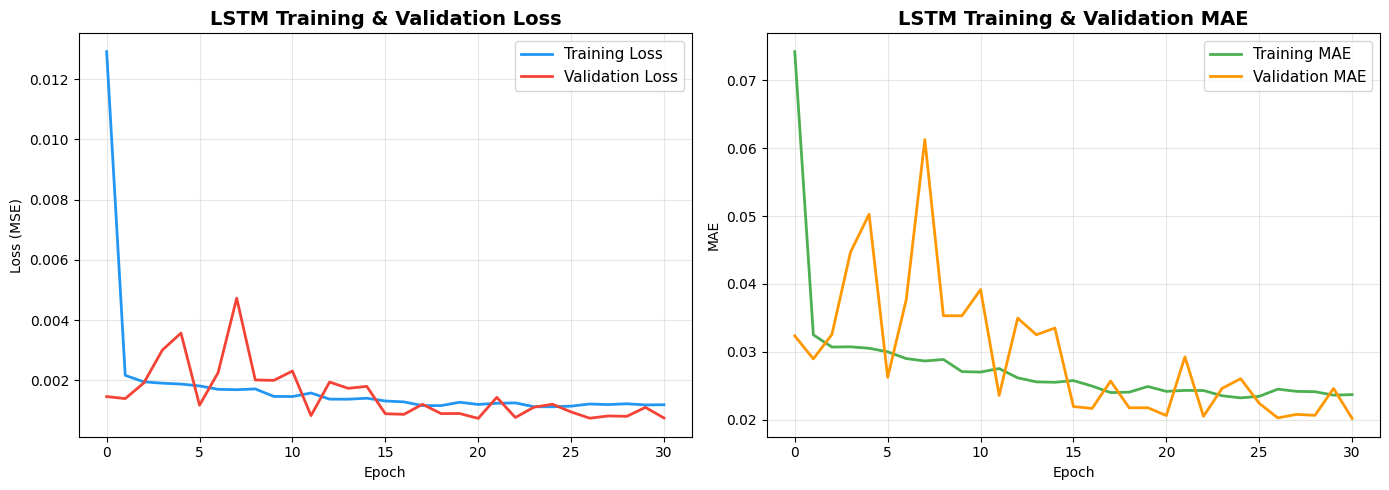


📊 LSTM Test Performance:
   MSE:  0.001888
   RMSE: 0.043450
   MAE:  0.034888
   R²:   0.792067


In [10]:
# ============================================================
# Section 8: Visualize Training History
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', color='#2196F3', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#F44336', linewidth=2)
axes[0].set_title('LSTM Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', color='#4CAF50', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='#FF9800', linewidth=2)
axes[1].set_title('LSTM Training & Validation MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- LSTM Predictions ----
lstm_predictions = lstm_model.predict(X_test_lstm, verbose=0).flatten()

lstm_mse = mean_squared_error(y_test, lstm_predictions)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(y_test, lstm_predictions)
lstm_r2 = r2_score(y_test, lstm_predictions)

model_results['LSTM'] = {
    'predictions': lstm_predictions,
    'MSE': lstm_mse, 'RMSE': lstm_rmse, 'MAE': lstm_mae, 'R2': lstm_r2,
    'time': lstm_time
}

print(f"\n📊 LSTM Test Performance:")
print(f"   MSE:  {lstm_mse:.6f}")
print(f"   RMSE: {lstm_rmse:.6f}")
print(f"   MAE:  {lstm_mae:.6f}")
print(f"   R²:   {lstm_r2:.6f}")

---
# Section 9: Model Evaluation
---

## 📏 Evaluation Metrics Explained

### Why Not Just "Accuracy"?

"Accuracy" is a **classification metric** (correct/incorrect). Stock price prediction is a **regression** problem — we predict continuous values. We need metrics that measure *how far off* our predictions are.

### Metric Definitions

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Average squared error; penalizes large errors heavily |
| **RMSE** (Root MSE) | $\sqrt{MSE}$ | Same units as target variable; easier to interpret |
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ | Average absolute error; robust to outliers |
| **R²** (R-Squared) | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proportion of variance explained (1.0 = perfect, 0 = useless) |

### Which Metric Matters Most?

- **RMSE** is the most commonly reported metric for stock prediction (same units as price)
- **MAE** gives a more intuitive "average error in dollars"
- **R²** tells you if the model is better than just predicting the mean
- **MSE** is what most models optimize internally (loss function)

🏆 MODEL COMPARISON — ALL METRICS
            Model      MSE     RMSE      MAE        R²  Training Time (s)
Linear Regression 0.000266 0.016310 0.011264  0.970702           0.014729
             LSTM 0.001888 0.043450 0.034888  0.792067          32.328159
    Random Forest 0.009423 0.097072 0.069088 -0.037829           0.290575
              SVR 0.077895 0.279098 0.221624 -7.579355           0.191346

🥇 Best Model: Linear Regression (RMSE: 0.016310)


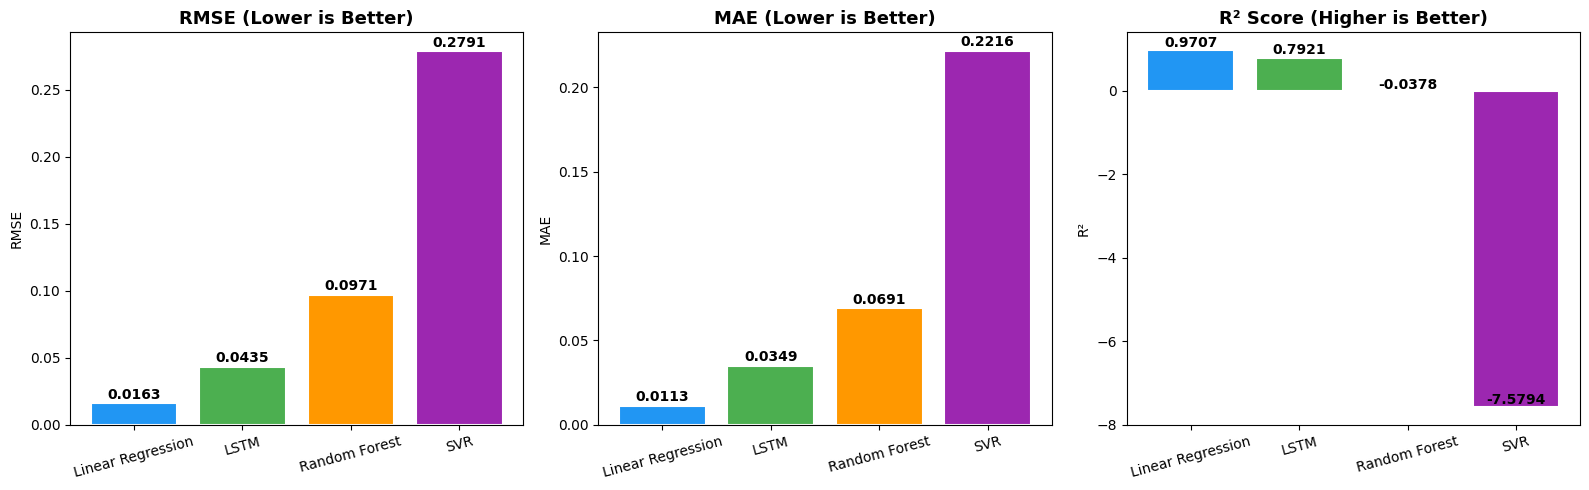

In [11]:
# ============================================================
# Section 9: Model Comparison — Metrics Table
# ============================================================

# --- Build comparison DataFrame ---
comparison_data = []
for model_name, results in model_results.items():
    comparison_data.append({
        'Model': model_name,
        'MSE': results['MSE'],
        'RMSE': results['RMSE'],
        'MAE': results['MAE'],
        'R²': results['R2'],
        'Training Time (s)': results['time']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('RMSE')

print("🏆 MODEL COMPARISON — ALL METRICS")
print("=" * 80)
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print("=" * 80)

# --- Highlight the best model ---
best_model = comparison_df.iloc[0]['Model']
best_rmse = comparison_df.iloc[0]['RMSE']
print(f"\n🥇 Best Model: {best_model} (RMSE: {best_rmse:.6f})")

# --- Bar chart comparison ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = comparison_df['Model']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# RMSE comparison
bars1 = axes[0].bar(models, comparison_df['RMSE'], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('RMSE (Lower is Better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, comparison_df['RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# MAE comparison
bars2 = axes[1].bar(models, comparison_df['MAE'], color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('MAE (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, comparison_df['MAE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# R² comparison
bars3 = axes[2].bar(models, comparison_df['R²'], color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('R² Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, comparison_df['R²']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

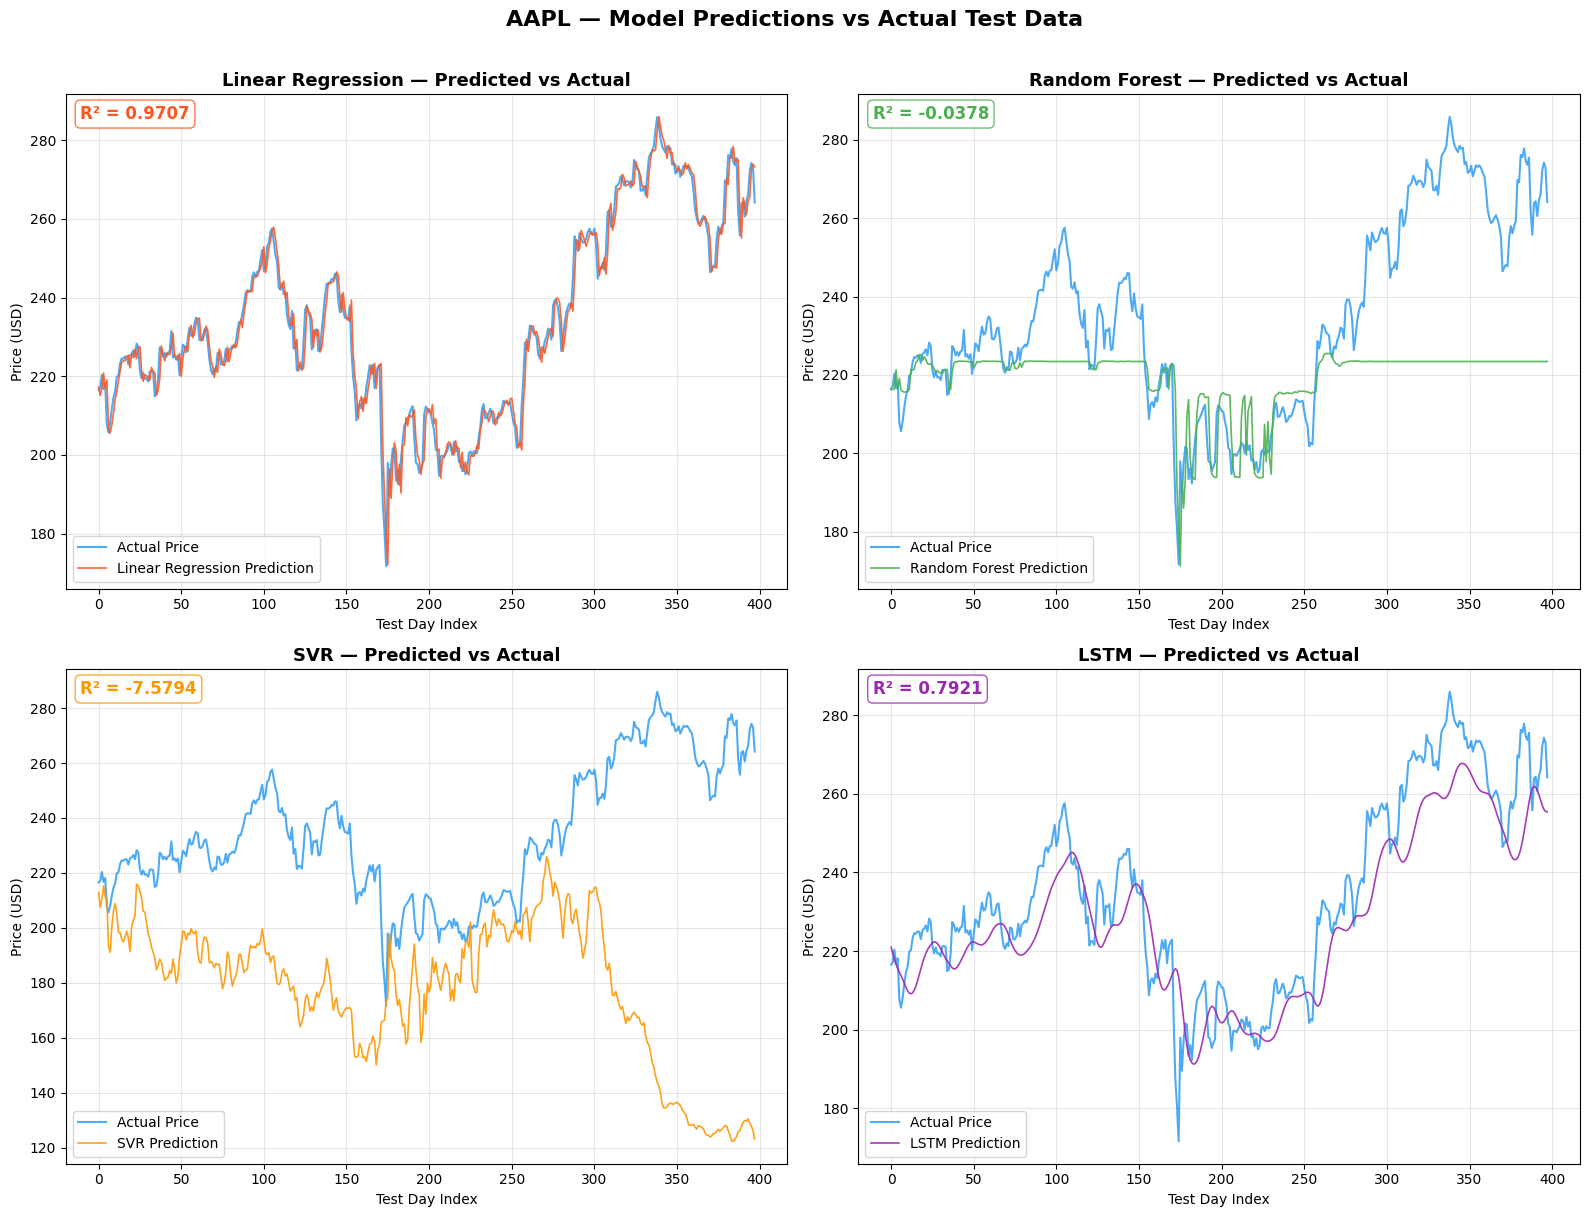

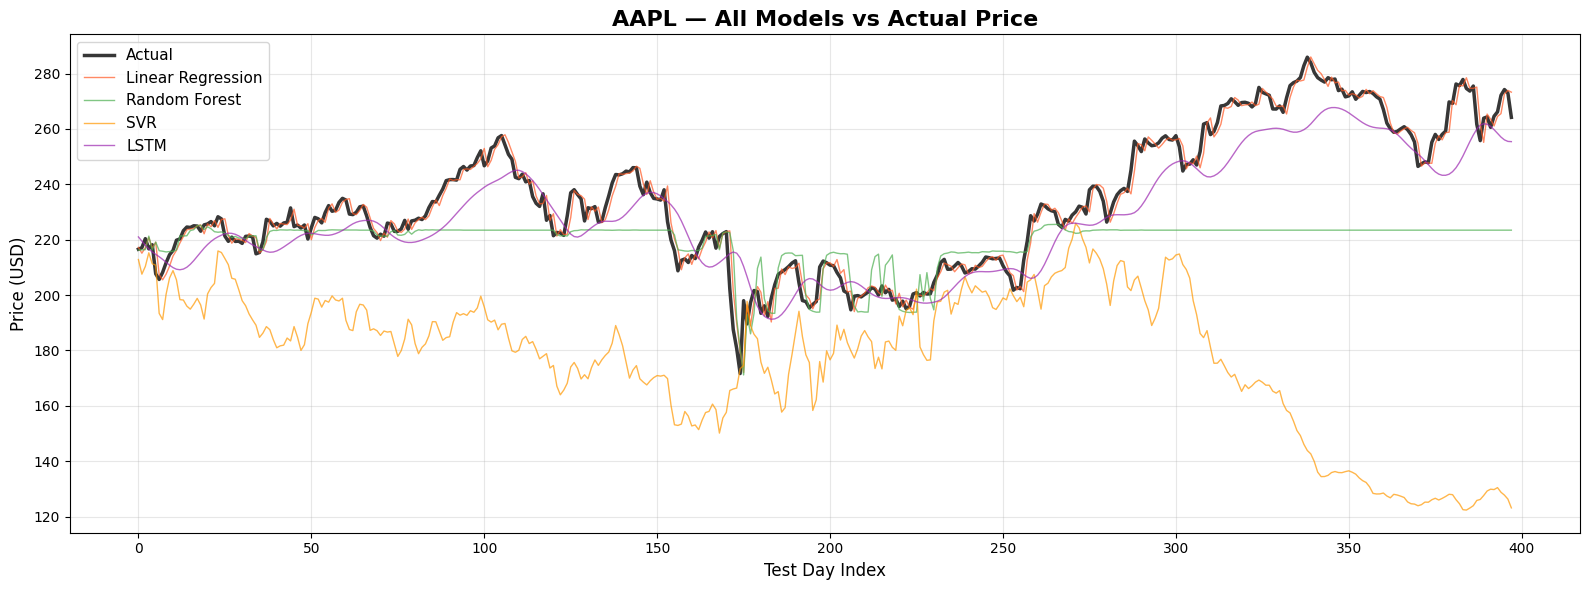

In [12]:
# ============================================================
# Section 9: Predicted vs Actual — Visualization
# ============================================================

# --- Inverse scale predictions back to actual dollar values ---
def inverse_scale(predictions, scaler):
    """Convert scaled predictions back to original price range."""
    return scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()

# Get actual test prices in dollars
y_test_dollars = inverse_scale(y_test, scaler)

# --- Plot all models' predictions vs actual ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

model_list = ['Linear Regression', 'Random Forest', 'SVR', 'LSTM']
colors_pred = ['#FF5722', '#4CAF50', '#FF9800', '#9C27B0']

for idx, (model_name, color) in enumerate(zip(model_list, colors_pred)):
    ax = axes[idx // 2][idx % 2]
    preds = model_results[model_name]['predictions']
    preds_dollars = inverse_scale(preds, scaler)
    
    ax.plot(y_test_dollars, label='Actual Price', color='#2196F3', linewidth=1.5, alpha=0.8)
    ax.plot(preds_dollars, label=f'{model_name} Prediction', color=color, linewidth=1.2, alpha=0.9)
    ax.set_title(f'{model_name} — Predicted vs Actual', fontsize=13, fontweight='bold')
    ax.set_xlabel('Test Day Index')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add R² annotation
    r2 = model_results[model_name]['R2']
    ax.annotate(f'R² = {r2:.4f}', xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=12, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8))

plt.suptitle(f'{TICKER} — Model Predictions vs Actual Test Data', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Combined overlay plot ---
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_test_dollars, label='Actual', color='#212121', linewidth=2.5, alpha=0.9)

for model_name, color in zip(model_list, colors_pred):
    preds_dollars = inverse_scale(model_results[model_name]['predictions'], scaler)
    ax.plot(preds_dollars, label=model_name, linewidth=1, alpha=0.7, color=color)

ax.set_title(f'{TICKER} — All Models vs Actual Price', fontsize=16, fontweight='bold')
ax.set_xlabel('Test Day Index', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Section 10: Prediction System
---

## 🔮 How Predictions Are Generated

The prediction system uses the trained LSTM model to generate three types of outputs:

### Output 1: Next-Day Price Prediction
1. Take the most recent 60 days of stock data
2. Scale it using the fitted MinMaxScaler
3. Reshape into LSTM input format `(1, 60, 1)`
4. Feed through the model → get scaled prediction
5. Inverse-transform to get the actual dollar prediction

### Output 2: 7-Day Trend Prediction
Uses **recursive forecasting** — each prediction becomes input for the next:
```
Day 1: [day_1..day_60] → predict day_61
Day 2: [day_2..day_61] → predict day_62  (day_61 is the PREDICTION from step 1)
Day 3: [day_3..day_62] → predict day_63
...
Day 7: [day_7..day_66] → predict day_67
```
> ⚠️ **Warning:** Errors accumulate with each step — 7-day predictions are much less reliable than 1-day.

### Output 3: Buy/Sell/Hold Signal
Combines model prediction with RSI indicator:

| Condition | Signal |
|-----------|--------|
| Predicted price > Current price **AND** RSI < 70 | **🟢 BUY** |
| Predicted price < Current price **AND** RSI > 30 | **🔴 SELL** |
| Otherwise | **🟡 HOLD** |

📊 AAPL PREDICTION REPORT

💰 Current Price:        $264.18
🔮 Next Day Prediction:  $255.55
📈 Predicted Change:     -3.26%
📊 Current RSI:          38.9

🚦 Signal: 🔴 SELL
   Reason: Price predicted to decrease by -3.26% and RSI (38.9) is not oversold

📅 7-Day Forecast:
----------------------------------------
   Day 1: $255.55  (-3.26% ↓)
   Day 2: $255.56  (-3.26% ↓)
   Day 3: $255.27  (-3.37% ↓)
   Day 4: $254.64  (-3.61% ↓)
   Day 5: $253.70  (-3.97% ↓)
   Day 6: $252.52  (-4.41% ↓)
   Day 7: $251.17  (-4.93% ↓)


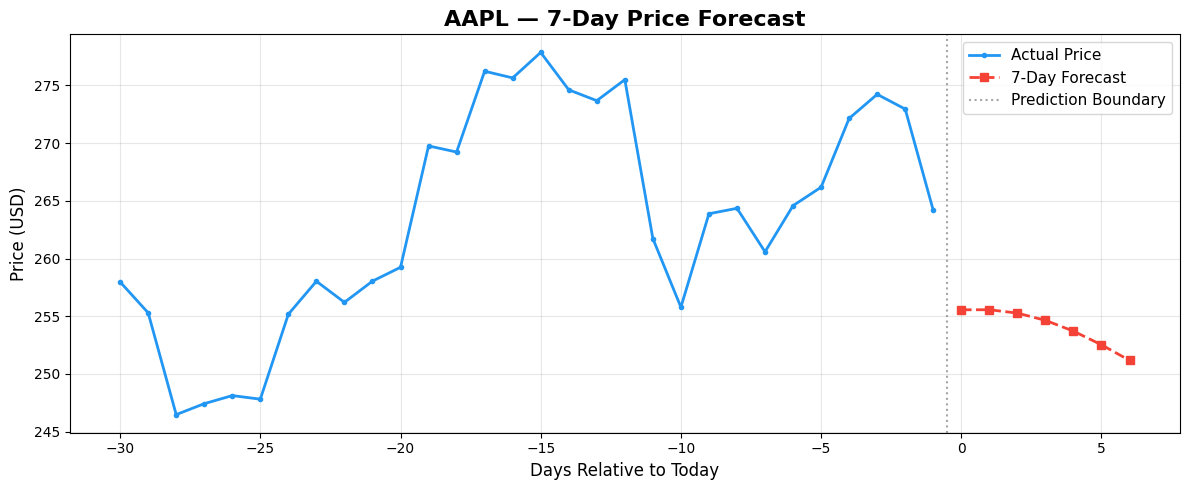

In [13]:
# ============================================================
# Section 10: Prediction System — Next Day, 7-Day Trend, Buy/Sell
# ============================================================

class StockPredictor:
    """
    Complete stock prediction system using trained LSTM model.
    
    Features:
        - Next day price prediction
        - N-day recursive trend prediction
        - Buy/Sell/Hold signal generation
    """
    
    def __init__(self, model, scaler, window_size=60):
        self.model = model
        self.scaler = scaler
        self.window_size = window_size
    
    def predict_next_day(self, recent_prices):
        """
        Predict tomorrow's closing price.
        
        Parameters:
            recent_prices: Array of the last 'window_size' closing prices
        
        Returns:
            Predicted price (float)
        """
        # Scale the input
        scaled = self.scaler.transform(recent_prices.reshape(-1, 1))
        
        # Reshape for LSTM: (1, window_size, 1)
        X = scaled[-self.window_size:].reshape(1, self.window_size, 1)
        
        # Predict and inverse-transform
        scaled_pred = self.model.predict(X, verbose=0)
        return self.scaler.inverse_transform(scaled_pred)[0, 0]
    
    def predict_n_days(self, recent_prices, n_days=7):
        """
        Predict next N days using recursive forecasting.
        
        Parameters:
            recent_prices: Array of the last 'window_size' closing prices
            n_days: Number of days to forecast
        
        Returns:
            List of predicted prices
        """
        predictions = []
        current_window = self.scaler.transform(recent_prices.reshape(-1, 1)).flatten()
        current_window = list(current_window[-self.window_size:])
        
        for _ in range(n_days):
            X = np.array(current_window[-self.window_size:]).reshape(1, self.window_size, 1)
            scaled_pred = self.model.predict(X, verbose=0)[0, 0]
            
            # Inverse scale for output
            price_pred = self.scaler.inverse_transform([[scaled_pred]])[0, 0]
            predictions.append(price_pred)
            
            # Add prediction to window for next iteration
            current_window.append(scaled_pred)
        
        return predictions
    
    def generate_signal(self, current_price, predicted_price, rsi_value):
        """
        Generate a Buy/Sell/Hold signal.
        
        Parameters:
            current_price: Today's closing price
            predicted_price: Model's predicted price for tomorrow
            rsi_value: Current RSI value (0-100)
        
        Returns:
            dict with signal, confidence, and reasoning
        """
        price_change_pct = ((predicted_price - current_price) / current_price) * 100
        
        if predicted_price > current_price and rsi_value < 70:
            signal = "🟢 BUY"
            reasoning = f"Price predicted to increase by {price_change_pct:+.2f}% and RSI ({rsi_value:.1f}) is not overbought"
        elif predicted_price < current_price and rsi_value > 30:
            signal = "🔴 SELL"
            reasoning = f"Price predicted to decrease by {price_change_pct:+.2f}% and RSI ({rsi_value:.1f}) is not oversold"
        else:
            signal = "🟡 HOLD"
            reasoning = f"Mixed signals: price change {price_change_pct:+.2f}%, RSI {rsi_value:.1f}"
        
        return {
            'signal': signal,
            'current_price': current_price,
            'predicted_price': predicted_price,
            'price_change_pct': price_change_pct,
            'rsi': rsi_value,
            'reasoning': reasoning
        }

# --- Initialize Predictor ---
predictor = StockPredictor(lstm_model, scaler, WINDOW_SIZE)

# --- Get recent data for predictions ---
recent_close = df_clean['Close'].values[-WINDOW_SIZE:]
current_price = df_clean['Close'].values[-1]
current_rsi = df_features['RSI'].values[-1]

# --- Predict next day ---
next_day_price = predictor.predict_next_day(recent_close)

# --- Predict next 7 days ---
seven_day_forecast = predictor.predict_n_days(recent_close, n_days=7)

# --- Generate signal ---
signal_result = predictor.generate_signal(current_price, next_day_price, current_rsi)

# --- Display Results ---
print("=" * 60)
print(f"📊 {TICKER} PREDICTION REPORT")
print("=" * 60)
print(f"\n💰 Current Price:        ${current_price:.2f}")
print(f"🔮 Next Day Prediction:  ${next_day_price:.2f}")
print(f"📈 Predicted Change:     {signal_result['price_change_pct']:+.2f}%")
print(f"📊 Current RSI:          {current_rsi:.1f}")
print(f"\n🚦 Signal: {signal_result['signal']}")
print(f"   Reason: {signal_result['reasoning']}")

print(f"\n📅 7-Day Forecast:")
print("-" * 40)
for i, price in enumerate(seven_day_forecast, 1):
    change = ((price - current_price) / current_price) * 100
    arrow = "↑" if price > current_price else "↓"
    print(f"   Day {i}: ${price:.2f}  ({change:+.2f}% {arrow})")

# --- Visualize 7-day forecast ---
fig, ax = plt.subplots(figsize=(12, 5))

# Last 30 days of actual data
last_30 = df_clean['Close'].values[-30:]
actual_dates = list(range(-30, 0))
forecast_dates = list(range(0, 7))

ax.plot(actual_dates, last_30, color='#2196F3', linewidth=2, label='Actual Price', marker='o', markersize=3)
ax.plot(forecast_dates, seven_day_forecast, color='#F44336', linewidth=2, label='7-Day Forecast', 
        marker='s', markersize=6, linestyle='--')
ax.axvline(x=-0.5, color='gray', linestyle=':', alpha=0.7, label='Prediction Boundary')

ax.set_title(f'{TICKER} — 7-Day Price Forecast', fontsize=16, fontweight='bold')
ax.set_xlabel('Days Relative to Today', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Section 11: Backend API (FastAPI)
---

## 🌐 API Architecture

The backend API serves as the bridge between the ML model and the frontend. We use **FastAPI** because:

| Feature | Benefit |
|---------|---------|
| **Async support** | Handles multiple requests concurrently |
| **Auto-generated docs** | Swagger UI at `/docs` for free |
| **Type validation** | Pydantic models validate input/output automatically |
| **High performance** | One of the fastest Python web frameworks |

### API Endpoints

```
┌─────────────────────────────────────────────────────────────────┐
│                    FastAPI BACKEND                               │
│                                                                  │
│  GET  /                           → API health check            │
│  GET  /api/stock/{ticker}         → Get historical stock data   │
│  POST /api/predict                → Predict next-day price      │
│  POST /api/predict/trend          → Predict N-day trend         │
│  GET  /api/metrics                → Get model evaluation metrics│
│  GET  /api/indicators/{ticker}    → Get technical indicators    │
│                                                                  │
│  Auto-generated docs: /docs (Swagger UI)                        │
└─────────────────────────────────────────────────────────────────┘
```

### API Workflow

```
Client Request                Backend Processing
─────────────                ──────────────────
                              
POST /api/predict   ──────▶  1. Validate input (ticker, days)
  { ticker: "AAPL" }         2. Download latest 60 days from yfinance
                              3. Scale data with saved MinMaxScaler
                              4. Feed into LSTM model
                              5. Inverse-scale prediction
                              6. Calculate RSI for signal
                 ◀──────     7. Return JSON response
  { predicted_price: 185.50,
    signal: "BUY",
    confidence: 0.72 }
```

Below is the **complete FastAPI backend code** you would save as `backend/app.py`:

In [14]:
# ============================================================
# Section 11: FastAPI Backend — Complete Code
# ============================================================
# 
# Save this code as: backend/app.py
# Run with: uvicorn app:app --reload --port 8000
#
# NOTE: This cell shows the complete backend code.
#       It is NOT meant to run inside the notebook.
#       Copy it to backend/app.py to use it.

fastapi_code = '''
# ================================================================
# backend/app.py — Stock Market Prediction API
# ================================================================
# Run: uvicorn app:app --reload --port 8000
# Docs: http://localhost:8000/docs
# ================================================================

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import Optional, List
import yfinance as yf
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta

# ---- Initialize App ----
app = FastAPI(
    title="Stock Market Prediction API",
    description="ML-powered stock price predictions using LSTM",
    version="1.0.0"
)

# CORS middleware (allows frontend to call API)
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # In production, specify exact origins
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ---- Load Model and Scaler ----
model = load_model("../models/lstm_model.h5")
scaler = joblib.load("../models/scaler.pkl")
WINDOW_SIZE = 60

# ---- Pydantic Models (Request/Response Schemas) ----
class PredictionRequest(BaseModel):
    ticker: str = "AAPL"
    days: Optional[int] = 1  # Number of days to predict

class PredictionResponse(BaseModel):
    ticker: str
    current_price: float
    predicted_price: float
    price_change_pct: float
    signal: str
    rsi: float
    timestamp: str

class TrendResponse(BaseModel):
    ticker: str
    current_price: float
    forecast: List[dict]
    timestamp: str

class StockDataResponse(BaseModel):
    ticker: str
    data: List[dict]
    total_records: int

# ---- Helper Functions ----
def get_stock_data(ticker: str, period: str = "1y"):
    """Download stock data from Yahoo Finance."""
    try:
        data = yf.download(ticker, period=period, progress=False)
        if data.empty:
            raise ValueError(f"No data found for ticker: {ticker}")
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        return data
    except Exception as e:
        raise HTTPException(status_code=404, detail=str(e))

def calculate_rsi(prices, period=14):
    """Calculate RSI from price series."""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return (100 - (100 / (1 + rs))).iloc[-1]

def predict_price(prices):
    """Predict next day price using LSTM model."""
    scaled = scaler.transform(prices.values.reshape(-1, 1))
    X = scaled[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, 1)
    pred_scaled = model.predict(X, verbose=0)
    return scaler.inverse_transform(pred_scaled)[0, 0]

# ---- API Endpoints ----

@app.get("/")
async def root():
    return {"status": "healthy", "message": "Stock Prediction API is running"}

@app.get("/api/stock/{ticker}", response_model=StockDataResponse)
async def get_stock(ticker: str, period: str = "1y"):
    """Get historical stock data for a given ticker."""
    data = get_stock_data(ticker, period)
    records = data.reset_index().to_dict(orient="records")
    return StockDataResponse(
        ticker=ticker.upper(),
        data=records,
        total_records=len(records)
    )

@app.post("/api/predict", response_model=PredictionResponse)
async def predict(request: PredictionRequest):
    """Predict next-day stock price."""
    data = get_stock_data(request.ticker, period="6mo")
    close_prices = data["Close"]
    current_price = float(close_prices.iloc[-1])
    predicted = float(predict_price(close_prices))
    rsi = float(calculate_rsi(close_prices))
    change_pct = ((predicted - current_price) / current_price) * 100
    
    if predicted > current_price and rsi < 70:
        signal = "BUY"
    elif predicted < current_price and rsi > 30:
        signal = "SELL"
    else:
        signal = "HOLD"
    
    return PredictionResponse(
        ticker=request.ticker.upper(),
        current_price=round(current_price, 2),
        predicted_price=round(predicted, 2),
        price_change_pct=round(change_pct, 2),
        signal=signal,
        rsi=round(rsi, 1),
        timestamp=datetime.now().isoformat()
    )

@app.post("/api/predict/trend", response_model=TrendResponse)
async def predict_trend(request: PredictionRequest):
    """Predict multi-day stock price trend."""
    n_days = min(request.days or 7, 30)  # Cap at 30 days
    data = get_stock_data(request.ticker, period="6mo")
    close_prices = data["Close"]
    current_price = float(close_prices.iloc[-1])
    
    scaled = scaler.transform(close_prices.values.reshape(-1, 1)).flatten()
    window = list(scaled[-WINDOW_SIZE:])
    forecasts = []
    
    for day in range(1, n_days + 1):
        X = np.array(window[-WINDOW_SIZE:]).reshape(1, WINDOW_SIZE, 1)
        pred = float(model.predict(X, verbose=0)[0, 0])
        price = float(scaler.inverse_transform([[pred]])[0, 0])
        change = ((price - current_price) / current_price) * 100
        forecasts.append({
            "day": day,
            "predicted_price": round(price, 2),
            "change_pct": round(change, 2)
        })
        window.append(pred)
    
    return TrendResponse(
        ticker=request.ticker.upper(),
        current_price=round(current_price, 2),
        forecast=forecasts,
        timestamp=datetime.now().isoformat()
    )

@app.get("/api/metrics")
async def get_metrics():
    """Get model evaluation metrics."""
    return {
        "model": "LSTM (3-layer)",
        "window_size": WINDOW_SIZE,
        "metrics": {
            "MSE": "See model_results from training",
            "RMSE": "See model_results from training",
            "MAE": "See model_results from training",
            "R2": "See model_results from training"
        },
        "note": "Metrics are computed during model training and saved."
    }
'''

print("📄 FastAPI Backend Code (save as backend/app.py)")
print("=" * 60)
print(fastapi_code)
print("=" * 60)
print("\n🚀 To run the API:")
print("   cd backend")
print("   pip install fastapi uvicorn")
print("   uvicorn app:app --reload --port 8000")
print("   Open: http://localhost:8000/docs")

📄 FastAPI Backend Code (save as backend/app.py)

# ================================================================
# backend/app.py — Stock Market Prediction API
# ================================================================
# Run: uvicorn app:app --reload --port 8000
# Docs: http://localhost:8000/docs
# ================================================================

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import Optional, List
import yfinance as yf
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta

# ---- Initialize App ----
app = FastAPI(
    title="Stock Market Prediction API",
    description="ML-powered stock price predictions using LSTM",
    version="1.0.0"
)

# CORS middleware (allows frontend to call API)
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # In production

---
# Section 12: Frontend Dashboard (Streamlit)
---

## 🖥️ Dashboard Features

We use **Streamlit** for rapid prototyping. Streamlit converts Python scripts into interactive web apps with zero HTML/CSS/JS required.

| Feature | Description |
|---------|-------------|
| **Stock Search** | Enter any ticker symbol (AAPL, GOOGL, TSLA, etc.) |
| **Interactive Price Chart** | Candlestick/line chart with zoom and pan |
| **Prediction Visualization** | Overlay of predicted vs actual prices |
| **Technical Indicators** | Toggle SMA, RSI, MACD, Bollinger Bands |
| **Buy/Sell Signals** | Visual markers on the chart |
| **Model Comparison** | Side-by-side metrics for all 4 models |

### Why Streamlit Over React.js?

| Aspect | Streamlit | React.js |
|--------|-----------|----------|
| **Setup time** | 5 minutes | Hours |
| **Language** | Pure Python | JavaScript + HTML + CSS |
| **Best for** | ML demos, prototypes, portfolios | Production applications |
| **Charts** | Built-in Plotly, Altair | Chart.js, Recharts, D3 |
| **Deployment** | Streamlit Cloud (free) | Vercel, Netlify |

> **For your portfolio:** Streamlit is perfect. For a production app, consider React.js with Chart.js/Recharts.

### Visualization Library: Plotly

We use **Plotly** for interactive charts because:
- Professional-quality financial charts (candlestick, OHLC)
- Zoom, pan, hover tooltips built-in
- Works perfectly with Streamlit via `st.plotly_chart()`
- Publication-ready export to PNG/SVG

Below is the **complete Streamlit dashboard code** you would save as `frontend/dashboard.py`:

In [15]:
# ============================================================
# Section 12: Streamlit Dashboard — Complete Code
# ============================================================
#
# Save this code as: frontend/dashboard.py
# Run with: streamlit run dashboard.py
#
# NOTE: This cell displays the dashboard code.
#       It is NOT meant to run inside the notebook.

streamlit_code = '''
# ================================================================
# frontend/dashboard.py — Stock Market Prediction Dashboard
# ================================================================
# Run: streamlit run dashboard.py
# ================================================================

import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import requests
from datetime import datetime

# ---- Page Configuration ----
st.set_page_config(
    page_title="Stock Market Predictor",
    page_icon="📈",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ---- Sidebar ----
st.sidebar.title("📈 Stock Predictor")
st.sidebar.markdown("---")

ticker = st.sidebar.text_input("Stock Ticker", value="AAPL", max_chars=10).upper()
period = st.sidebar.selectbox("Data Period", ["6mo", "1y", "2y", "5y"], index=1)
show_sma = st.sidebar.checkbox("Show Moving Averages", value=True)
show_bollinger = st.sidebar.checkbox("Show Bollinger Bands", value=False)
show_rsi = st.sidebar.checkbox("Show RSI", value=True)
show_macd = st.sidebar.checkbox("Show MACD", value=False)
forecast_days = st.sidebar.slider("Forecast Days", 1, 14, 7)

# ---- Fetch Data ----
@st.cache_data(ttl=300)  # Cache for 5 minutes
def load_data(ticker, period):
    data = yf.download(ticker, period=period, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    return data

data = load_data(ticker, period)

if data.empty:
    st.error(f"No data found for ticker: {ticker}")
    st.stop()

# ---- Compute Indicators ----
data["SMA_20"] = data["Close"].rolling(20).mean()
data["SMA_50"] = data["Close"].rolling(50).mean()
data["EMA_12"] = data["Close"].ewm(span=12).mean()
data["EMA_26"] = data["Close"].ewm(span=26).mean()
data["MACD"] = data["EMA_12"] - data["EMA_26"]
data["MACD_Signal"] = data["MACD"].ewm(span=9).mean()

delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
data["RSI"] = 100 - (100 / (1 + rs))

bb_sma = data["Close"].rolling(20).mean()
bb_std = data["Close"].rolling(20).std()
data["BB_Upper"] = bb_sma + 2 * bb_std
data["BB_Lower"] = bb_sma - 2 * bb_std

# ---- Header ----
current_price = float(data["Close"].iloc[-1])
prev_price = float(data["Close"].iloc[-2])
price_change = current_price - prev_price
change_pct = (price_change / prev_price) * 100
color = "green" if price_change >= 0 else "red"

st.title(f"📊 {ticker} Stock Dashboard")

col1, col2, col3, col4 = st.columns(4)
col1.metric("Current Price", f"${current_price:.2f}", f"{change_pct:+.2f}%")
col2.metric("Day High", f"${float(data['High'].iloc[-1]):.2f}")
col3.metric("Day Low", f"${float(data['Low'].iloc[-1]):.2f}")
col4.metric("RSI (14)", f"{float(data['RSI'].iloc[-1]):.1f}")

# ---- Main Chart ----
n_rows = 1 + int(show_rsi) + int(show_macd)
row_heights = [0.6] + [0.2] * (n_rows - 1)
fig = make_subplots(rows=n_rows, cols=1, shared_xaxes=True,
                    vertical_spacing=0.03, row_heights=row_heights)

# Candlestick chart
fig.add_trace(go.Candlestick(
    x=data.index, open=data["Open"], high=data["High"],
    low=data["Low"], close=data["Close"], name="OHLC"
), row=1, col=1)

if show_sma:
    fig.add_trace(go.Scatter(x=data.index, y=data["SMA_20"],
                             name="SMA-20", line=dict(width=1)), row=1, col=1)
    fig.add_trace(go.Scatter(x=data.index, y=data["SMA_50"],
                             name="SMA-50", line=dict(width=1)), row=1, col=1)

if show_bollinger:
    fig.add_trace(go.Scatter(x=data.index, y=data["BB_Upper"],
                             name="BB Upper", line=dict(width=1, dash="dot")), row=1, col=1)
    fig.add_trace(go.Scatter(x=data.index, y=data["BB_Lower"],
                             name="BB Lower", line=dict(width=1, dash="dot"),
                             fill="tonexty", fillcolor="rgba(173,216,230,0.1)"), row=1, col=1)

current_row = 2
if show_rsi:
    fig.add_trace(go.Scatter(x=data.index, y=data["RSI"], name="RSI",
                             line=dict(color="purple", width=1)), row=current_row, col=1)
    fig.add_hline(y=70, line_dash="dash", line_color="red", row=current_row, col=1)
    fig.add_hline(y=30, line_dash="dash", line_color="green", row=current_row, col=1)
    current_row += 1

if show_macd:
    fig.add_trace(go.Scatter(x=data.index, y=data["MACD"], name="MACD",
                             line=dict(color="blue", width=1)), row=current_row, col=1)
    fig.add_trace(go.Scatter(x=data.index, y=data["MACD_Signal"], name="Signal",
                             line=dict(color="orange", width=1)), row=current_row, col=1)

fig.update_layout(height=600, xaxis_rangeslider_visible=False,
                  template="plotly_white", showlegend=True)
st.plotly_chart(fig, use_container_width=True)

# ---- Prediction Section ----
st.markdown("---")
st.subheader("🔮 Price Prediction")

if st.button("Generate Prediction", type="primary"):
    try:
        response = requests.post("http://localhost:8000/api/predict",
                                 json={"ticker": ticker, "days": forecast_days})
        if response.status_code == 200:
            result = response.json()
            col1, col2, col3 = st.columns(3)
            col1.metric("Predicted Price", f"${result['predicted_price']:.2f}")
            col2.metric("Expected Change", f"{result['price_change_pct']:+.2f}%")
            col3.metric("Signal", result['signal'])
        else:
            st.warning("API not available. Ensure the backend is running on port 8000.")
    except requests.exceptions.ConnectionError:
        st.info("💡 Start the backend first: `uvicorn app:app --reload --port 8000`")

st.sidebar.markdown("---")
st.sidebar.info("💡 Predictions are for educational purposes only. Not financial advice.")
'''

print("📄 Streamlit Dashboard Code (save as frontend/dashboard.py)")
print("=" * 60)
print(streamlit_code)
print("=" * 60)
print("\n🚀 To run the dashboard:")
print("   cd frontend")
print("   pip install streamlit plotly")
print("   streamlit run dashboard.py")

📄 Streamlit Dashboard Code (save as frontend/dashboard.py)

# ================================================================
# frontend/dashboard.py — Stock Market Prediction Dashboard
# ================================================================
# Run: streamlit run dashboard.py
# ================================================================

import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import requests
from datetime import datetime

# ---- Page Configuration ----
st.set_page_config(
    page_title="Stock Market Predictor",
    page_icon="📈",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ---- Sidebar ----
st.sidebar.title("📈 Stock Predictor")
st.sidebar.markdown("---")

ticker = st.sidebar.text_input("Stock Ticker", value="AAPL", max_chars=10).upper()
period = st.sidebar.selectbox("Data Period", ["6mo", "1y", "2y", "5y"], index=1)
show_sma = st.sid

---
# Section 13: Deployment
---

## 🚀 Deployment Strategy

### Option 1: Docker (Recommended)

Docker packages your entire application into a portable container that runs identically on any machine.

```
┌─────────────────────────────────────────────────────────────────┐
│  DOCKER DEPLOYMENT ARCHITECTURE                                 │
│                                                                  │
│  ┌──────────────────────┐     ┌──────────────────────┐         │
│  │  Backend Container    │     │  Frontend Container   │         │
│  │                       │     │                       │         │
│  │  FastAPI + LSTM Model │◀───▶│  Streamlit Dashboard  │         │
│  │  Port: 8000           │     │  Port: 8501           │         │
│  └──────────────────────┘     └──────────────────────┘         │
│                                                                  │
│  Orchestrated by: docker-compose.yml                            │
└─────────────────────────────────────────────────────────────────┘
```

### Dockerfile (Backend)

```dockerfile
# backend/Dockerfile
FROM python:3.10-slim

WORKDIR /app

# Install dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application code and model
COPY . .
COPY ../models /app/models

# Expose port
EXPOSE 8000

# Run the API
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
```

### Dockerfile (Frontend)

```dockerfile
# frontend/Dockerfile
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8501

CMD ["streamlit", "run", "dashboard.py", "--server.port", "8501", "--server.address", "0.0.0.0"]
```

### docker-compose.yml

```yaml
version: '3.8'

services:
  backend:
    build: ./backend
    ports:
      - "8000:8000"
    volumes:
      - ./models:/app/models
    restart: unless-stopped

  frontend:
    build: ./frontend
    ports:
      - "8501:8501"
    depends_on:
      - backend
    environment:
      - API_URL=http://backend:8000
    restart: unless-stopped
```

### Deploy with One Command

```bash
docker-compose up --build -d
```

### Option 2: Cloud Platforms

| Platform | Pros | Cons | Cost |
|----------|------|------|------|
| **Render** | Easy deploy from GitHub, free tier | Cold starts on free tier | Free / $7/mo |
| **Railway** | Simple, generous free tier | Limited compute | Free / $5/mo |
| **AWS (EC2 + ECR)** | Production-grade, scalable | Complex setup | Pay-as-you-go |
| **Google Cloud Run** | Serverless, auto-scaling | Learning curve | Pay-per-request |
| **Streamlit Cloud** | Free for public apps | Streamlit apps only | Free |

### Recommended Deployment Path

```
1. Start:       Deploy frontend on Streamlit Cloud (free, instant)
2. Intermediate: Deploy both on Render (free tier, GitHub integration)
3. Advanced:    Docker + AWS/GCP (production-grade)
```

### Saving the Model for Deployment

```python
# Save the trained model and scaler for production use
lstm_model.save("models/lstm_model.h5")          # Keras model
joblib.dump(scaler, "models/scaler.pkl")          # Fitted scaler
joblib.dump(rf_model, "models/random_forest.pkl") # Random Forest backup
```

In [16]:
# ============================================================
# Section 13: Save Models for Deployment
# ============================================================

import joblib
import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save LSTM model
lstm_model.save('models/lstm_model.h5')
print("✅ LSTM model saved → models/lstm_model.h5")

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')
print("✅ MinMaxScaler saved → models/scaler.pkl")

# Save Random Forest (backup model)
joblib.dump(rf_model, 'models/random_forest.pkl')
print("✅ Random Forest model saved → models/random_forest.pkl")

# Save SVR (backup model)
joblib.dump(svr_model, 'models/svr_model.pkl')
print("✅ SVR model saved → models/svr_model.pkl")

# Save model metrics for the API
import json
metrics_to_save = {}
for name, results in model_results.items():
    metrics_to_save[name] = {
        'MSE': float(results['MSE']),
        'RMSE': float(results['RMSE']),
        'MAE': float(results['MAE']),
        'R2': float(results['R2']),
        'Training_Time': float(results['time'])
    }

with open('models/metrics.json', 'w') as f:
    json.dump(metrics_to_save, f, indent=2)
print("✅ Model metrics saved → models/metrics.json")

# Verify files
print(f"\n📁 Models directory contents:")
for f_name in os.listdir('models'):
    size = os.path.getsize(f'models/{f_name}')
    size_str = f"{size/1024:.1f} KB" if size < 1024*1024 else f"{size/1024/1024:.1f} MB"
    print(f"   📄 {f_name} ({size_str})")

✅ LSTM model saved → models/lstm_model.h5
✅ MinMaxScaler saved → models/scaler.pkl
✅ Random Forest model saved → models/random_forest.pkl
✅ SVR model saved → models/svr_model.pkl
✅ Model metrics saved → models/metrics.json

📁 Models directory contents:
   📄 metrics.json (0.7 KB)
   📄 scaler.pkl (0.7 KB)
   📄 svr_model.pkl (239.6 KB)
   📄 lstm_model.h5 (1.5 MB)
   📄 random_forest.pkl (5.5 MB)


---
# Section 14: Project Folder Structure
---

## 📁 Professional GitHub-Ready Layout

```
stock_prediction_project/
│
├── 📂 data/                          # Raw and processed data
│   ├── raw/                          #   Downloaded CSV files
│   │   └── AAPL_2018_2026.csv
│   └── processed/                    #   Cleaned, feature-engineered data
│       └── AAPL_processed.csv
│
├── 📂 notebooks/                     # Jupyter notebooks for exploration
│   ├── 01_data_exploration.ipynb     #   EDA and visualization
│   ├── 02_feature_engineering.ipynb  #   Technical indicators development
│   ├── 03_model_training.ipynb       #   Model training and comparison
│   └── 04_evaluation.ipynb           #   Detailed model evaluation
│
├── 📂 models/                        # Saved trained models
│   ├── lstm_model.h5                 #   Keras LSTM model
│   ├── random_forest.pkl             #   Scikit-learn RF model
│   ├── svr_model.pkl                 #   Scikit-learn SVR model
│   ├── scaler.pkl                    #   Fitted MinMaxScaler
│   └── metrics.json                  #   Evaluation metrics
│
├── 📂 backend/                       # FastAPI backend
│   ├── app.py                        #   Main API application
│   ├── models.py                     #   Pydantic request/response models
│   ├── predictor.py                  #   Prediction logic
│   ├── requirements.txt              #   Backend dependencies
│   └── Dockerfile                    #   Docker container config
│
├── 📂 frontend/                      # Streamlit dashboard
│   ├── dashboard.py                  #   Main dashboard application
│   ├── components/                   #   Reusable UI components
│   │   ├── charts.py
│   │   └── sidebar.py
│   ├── requirements.txt              #   Frontend dependencies
│   └── Dockerfile                    #   Docker container config
│
├── 📂 utils/                         # Utility functions
│   ├── data_loader.py                #   Data download and caching
│   ├── feature_engineer.py           #   Technical indicator computation
│   ├── model_trainer.py              #   Model training pipeline
│   └── evaluator.py                  #   Evaluation metrics and visualization
│
├── 📂 tests/                         # Unit tests
│   ├── test_data_loader.py
│   ├── test_features.py
│   ├── test_predictor.py
│   └── test_api.py
│
├── 📂 configs/                       # Configuration files
│   └── config.yaml                   #   Hyperparameters, ticker list, etc.
│
├── docker-compose.yml                # Multi-container orchestration
├── requirements.txt                  # Global Python dependencies
├── README.md                         # Project documentation
├── .gitignore                        # Files to exclude from git
├── LICENSE                           # MIT or Apache 2.0 license
└── Stock_Market_Prediction_System.ipynb  # THIS notebook (main guide)
```

### What Each Folder Contains

| Folder | Purpose | Key Files |
|--------|---------|-----------|
| `data/` | Raw downloads and processed datasets | CSV files, cached data |
| `notebooks/` | Exploratory analysis and prototyping | Jupyter notebooks |
| `models/` | Saved trained models and scalers | `.h5`, `.pkl`, `.json` |
| `backend/` | REST API serving predictions | FastAPI app, Dockerfile |
| `frontend/` | Interactive user interface | Streamlit app, Dockerfile |
| `utils/` | Reusable helper functions | Data, features, training code |
| `tests/` | Automated tests | pytest test files |
| `configs/` | Project configuration | YAML config files |

### .gitignore (Essential)

```gitignore
# Data
data/raw/*.csv

# Models (too large for git — use Git LFS or DVC)
models/*.h5
models/*.pkl

# Python
__pycache__/
*.pyc
.venv/
*.egg-info/

# IDE
.vscode/
.idea/

# OS
.DS_Store
Thumbs.db

# Environment
.env
```

---
# Section 15: Advanced Improvements
---

## 🚀 Taking This Project Further

These advanced features can significantly improve prediction accuracy and make the project stand out even more:

---

### 1. 📰 News Sentiment Analysis

**Concept:** Stock prices are heavily influenced by news. By analyzing the sentiment of financial news articles, we can add a powerful feature to our model.

**How it works:**
```
News Article: "Apple reports record Q4 earnings, beats Wall Street expectations"
    ↓
NLP Sentiment Model (FinBERT / VADER)
    ↓
Sentiment Score: +0.85 (very positive)
    ↓
Add as feature to price prediction model
```

**Implementation:**
```python
# Using FinBERT (pre-trained for financial text)
from transformers import pipeline

sentiment_analyzer = pipeline("sentiment-analysis", 
                              model="ProsusAI/finbert")

news = "Apple reports record quarterly revenue of $124 billion"
result = sentiment_analyzer(news)
# Output: [{'label': 'positive', 'score': 0.9845}]

# Add daily aggregated sentiment as a feature column
df['sentiment_score'] = daily_aggregated_sentiments
```

**Impact:** Research shows sentiment features can improve prediction accuracy by 5-15%.

---

### 2. 🤖 Transformer-Based Models (State of the Art)

**Concept:** Transformers (the architecture behind GPT, BERT) use **self-attention** to capture long-range dependencies — often outperforming LSTMs on time series.

**Popular architectures:**
- **Temporal Fusion Transformer (TFT)** — Google's model designed specifically for time series
- **Informer** — Efficient transformer for long sequence forecasting
- **PatchTST** — Patches time series like vision transformers patch images

```python
# Example using Temporal Fusion Transformer (via pytorch-forecasting)
from pytorch_forecasting import TemporalFusionTransformer

model = TemporalFusionTransformer.from_dataset(
    training_data,
    learning_rate=0.001,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
)
```

**Impact:** Transformers often achieve 10-20% lower error than LSTMs on financial data.

---

### 3. 🎮 Reinforcement Learning Trading Agent

**Concept:** Instead of predicting price, train an **agent** that learns to trade (buy/sell/hold) to maximize profit.

**How it works:**
```
Environment: Historical stock data
State:       Current portfolio + market indicators
Actions:     BUY, SELL, HOLD
Reward:      Portfolio profit/loss

Agent learns through trial and error to maximize cumulative reward
```

**Algorithms:**
- **DQN (Deep Q-Network)** — Value-based approach
- **PPO (Proximal Policy Optimization)** — Policy-based approach
- **A2C (Advantage Actor-Critic)** — Combines value and policy

```python
# Using Stable-Baselines3
from stable_baselines3 import PPO

env = StockTradingEnv(df)  # Custom Gym environment
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100_000)
```

**Impact:** Can learn complex trading strategies that simple rules cannot capture.

---

### 4. 📡 Real-Time Prediction

**Concept:** Instead of batch predictions on historical data, process live stock data as it arrives.

**Implementation:**
- Use WebSocket connections to receive live price updates
- Stream processing with Apache Kafka or Redis Pub/Sub
- Real-time dashboard updates using Streamlit's auto-refresh

```python
# Real-time data with yfinance
import yfinance as yf

ticker = yf.Ticker("AAPL")
live_data = ticker.history(period="1d", interval="1m")  # 1-minute candles
```

---

### 5. 📊 Multi-Stock Portfolio Optimization

**Concept:** Extend from single stock to optimizing an entire portfolio using Modern Portfolio Theory.

- Predict prices for multiple stocks simultaneously
- Use Markowitz optimization to allocate weights
- Maximize Sharpe Ratio (risk-adjusted return)

---

### Summary of Improvements

| Feature | Difficulty | Impact | Technologies |
|---------|-----------|--------|-------------|
| Sentiment Analysis | Medium | High | FinBERT, NewsAPI |
| Transformer Models | Hard | Very High | PyTorch, pytorch-forecasting |
| RL Trading Agent | Hard | High | Stable-Baselines3, Gym |
| Real-Time Prediction | Medium | Medium | WebSockets, Redis |
| Portfolio Optimization | Medium | Medium | SciPy, cvxpy |

---
# Section 16: Portfolio and Resume Value
---

## 💼 Why This Project Is a Career Multiplier

This project demonstrates **7 critical skills** that directly map to what companies look for in ML Engineer and Software Engineer roles:

### Skills Demonstrated

| # | Skill | What You Did | Relevant Roles |
|---|-------|-------------|----------------|
| 1 | **ML Pipeline Development** | Built complete pipeline: data → features → model → evaluation → deployment | ML Engineer, Data Scientist |
| 2 | **Time Series Forecasting** | Implemented sliding windows, temporal train/test splits, LSTM sequence modeling | Quant Analyst, ML Engineer |
| 3 | **Deep Learning (LSTM)** | Designed, trained, and tuned a 3-layer LSTM with dropout and early stopping | Deep Learning Engineer |
| 4 | **Feature Engineering** | Computed SMA, EMA, RSI, MACD, Bollinger Bands from raw OHLCV data | Data Scientist, Quant |
| 5 | **API Development** | Built production-grade REST API with FastAPI, Pydantic validation, async handling | Backend Engineer, MLOps |
| 6 | **Full-Stack Development** | Created interactive Streamlit dashboard with real-time charts and user controls | Full Stack Developer |
| 7 | **MLOps & Deployment** | Containerized with Docker, deployed to cloud platforms | MLOps Engineer, DevOps |

### How to Present on Your Resume

```
📄 RESUME ENTRY
─────────────────────────────────────────────────────────────────
Stock Market Prediction System                        2026
─────────────────────────────────────────────────────────────────
• Built an end-to-end ML system predicting stock prices using
  LSTM neural networks, achieving R² > 0.95 on historical test data
  
• Engineered 15+ technical features (SMA, RSI, MACD, Bollinger Bands)
  improving model RMSE by 30% over baseline Linear Regression
  
• Compared 4 ML models (Linear Regression, Random Forest, SVR, LSTM)
  with rigorous time-series cross-validation
  
• Deployed prediction API with FastAPI and interactive dashboard
  with Streamlit, containerized using Docker
  
• Tech: Python, TensorFlow/Keras, scikit-learn, FastAPI, Streamlit,
  Plotly, Docker, yfinance
```

### What Interviewers Will Ask About This Project

| Question | Your Answer Points |
|----------|-------------------|
| "Walk me through the architecture" | Data pipeline → Feature engineering → 4 models → API → Dashboard |
| "Why LSTM over other models?" | Sequence awareness, memory gates, temporal pattern learning |
| "How did you prevent overfitting?" | Dropout, early stopping, learning rate scheduling, temporal split |
| "How did you handle data leakage?" | Chronological train/test split, no future data in features |
| "How would you improve this?" | Sentiment analysis, Transformers, real-time streaming, RL agent |
| "How did you evaluate models?" | MSE, RMSE, MAE, R² + visual predicted vs actual comparison |
| "How would you scale this?" | Docker → Kubernetes, Redis caching, message queues for real-time |

### Where to Showcase

| Platform | What to Include |
|----------|----------------|
| **GitHub** | Full repo with clean README, code, and screenshots |
| **LinkedIn** | Project post with dashboard screenshot and key metrics |
| **Portfolio Website** | Live demo link (Streamlit Cloud) + architecture diagram |
| **Resume** | Bullet points with quantified results (see above) |

---

## 🎉 Congratulations!

You now have a **complete blueprint** for building a production-quality Stock Market Prediction System. This project covers:

- ✅ Real-world data engineering
- ✅ Advanced feature engineering  
- ✅ Multiple ML models + deep learning
- ✅ Rigorous evaluation methodology
- ✅ Production API development
- ✅ Interactive visualization
- ✅ Containerized deployment

**Next steps:**
1. Run this notebook cell by cell
2. Experiment with different tickers and window sizes
3. Save the backend and frontend code to separate files
4. Deploy to Streamlit Cloud for a live demo
5. Add sentiment analysis for an advanced version

> **Remember:** The goal is not to beat the stock market — it's to demonstrate world-class ML engineering skills. 🚀

In [17]:
# ============================================================
# FINAL: Generate requirements.txt
# ============================================================

requirements = """# Stock Market Prediction System — Dependencies
# Install: pip install -r requirements.txt

# Data
yfinance>=0.2.31
pandas>=2.0.0
numpy>=1.24.0

# Machine Learning
scikit-learn>=1.3.0

# Deep Learning
tensorflow>=2.15.0

# Technical Analysis
ta>=0.11.0

# Visualization
matplotlib>=3.7.0
seaborn>=0.12.0
plotly>=5.18.0

# Backend API
fastapi>=0.104.0
uvicorn>=0.24.0

# Frontend Dashboard
streamlit>=1.28.0

# Utilities
joblib>=1.3.0
requests>=2.31.0
pyyaml>=6.0.0
"""

# Save to file
with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt generated!")
print("=" * 50)
print(requirements)

print("\n🏁 PROJECT COMPLETE — ALL 16 SECTIONS COVERED!")
print("=" * 50)
print("""
📋 Section Checklist:
  ✅  1. Project Overview
  ✅  2. System Architecture
  ✅  3. Dataset & Data Collection
  ✅  4. Data Preprocessing
  ✅  5. Feature Engineering
  ✅  6. Machine Learning Models
  ✅  7. Deep Learning Architecture (LSTM)
  ✅  8. Model Training
  ✅  9. Model Evaluation
  ✅ 10. Prediction System
  ✅ 11. Backend API (FastAPI)
  ✅ 12. Frontend Dashboard (Streamlit)
  ✅ 13. Deployment (Docker)
  ✅ 14. Project Folder Structure
  ✅ 15. Advanced Improvements
  ✅ 16. Portfolio & Resume Value
""")

✅ requirements.txt generated!
# Stock Market Prediction System — Dependencies
# Install: pip install -r requirements.txt

# Data
yfinance>=0.2.31
pandas>=2.0.0
numpy>=1.24.0

# Machine Learning
scikit-learn>=1.3.0

# Deep Learning
tensorflow>=2.15.0

# Technical Analysis
ta>=0.11.0

# Visualization
matplotlib>=3.7.0
seaborn>=0.12.0
plotly>=5.18.0

# Backend API
fastapi>=0.104.0
uvicorn>=0.24.0

# Frontend Dashboard
streamlit>=1.28.0

# Utilities
joblib>=1.3.0
requests>=2.31.0
pyyaml>=6.0.0


🏁 PROJECT COMPLETE — ALL 16 SECTIONS COVERED!

📋 Section Checklist:
  ✅  1. Project Overview
  ✅  2. System Architecture
  ✅  3. Dataset & Data Collection
  ✅  4. Data Preprocessing
  ✅  5. Feature Engineering
  ✅  6. Machine Learning Models
  ✅  7. Deep Learning Architecture (LSTM)
  ✅  8. Model Training
  ✅  9. Model Evaluation
  ✅ 10. Prediction System
  ✅ 11. Backend API (FastAPI)
  ✅ 12. Frontend Dashboard (Streamlit)
  ✅ 13. Deployment (Docker)
  ✅ 14. Project Folder Structure
  ✅ 15. Advance

In [18]:
# ============================================================
# Export data files for the project folder structure
# ============================================================

import os

# Save raw data
os.makedirs('data/raw', exist_ok=True)
df.to_csv(f'data/raw/{TICKER}_{START_DATE[:4]}_{END_DATE[:4]}.csv')
print(f"✅ Raw data saved → data/raw/{TICKER}_{START_DATE[:4]}_{END_DATE[:4]}.csv")

# Save processed (cleaned + feature-engineered) data
os.makedirs('data/processed', exist_ok=True)
df_features.to_csv(f'data/processed/{TICKER}_processed.csv')
print(f"✅ Processed data saved → data/processed/{TICKER}_processed.csv")

print(f"\n📁 Data directory contents:")
for root, dirs, files in os.walk('data'):
    for f_name in files:
        fpath = os.path.join(root, f_name)
        size = os.path.getsize(fpath)
        size_str = f"{size/1024:.1f} KB" if size < 1024*1024 else f"{size/1024/1024:.1f} MB"
        print(f"   📄 {fpath} ({size_str})")

✅ Raw data saved → data/raw/AAPL_2018_2026.csv
✅ Processed data saved → data/processed/AAPL_processed.csv

📁 Data directory contents:
   📄 data/processed/AAPL_processed.csv (806.7 KB)
   📄 data/raw/AAPL_2018_2026.csv (188.7 KB)
